# Model Improvement for Poker games profitable moves predictor


#### - The data was created in the other Notebook "01_Poker_data_preprocessing.ipynb".
#### - The exploratory data analysis was done in the other Notebook "02_Poker_exploratory_data_analysis.ipynb".
#### - The baseline model was created in the other Notebook "03_Poker_baseline_modeling.ipynb".


# What models should I improve ?

The research question is "Is it possible to predict the most profitable moves to play in a poker game ?"
We expect to build a model to answer the research question. Based on the input data, the model should be able to make 2 predictions:
- What the player's next action should be (fold, check/call, or raise). For each move there is only one of those 3 choices. For this point, we will need a classification model to predict the action. We already created a baseline model for this and we will try to improve this model with better performance in this notebook
- In case the action predicted is "raise", what should be the best amount to raise to be the most profitable possible. In the other cases when the choice was fold or check/call, there is no need to predict any amount as the player won't need to bet anything. For this point, we will need another regression model to predict the amount to raise. We already created a baseline model for this and we will try to improve this model with better performance in this notebook

To improve my baseline model, I added 3 new columns to the dataset "poker_games.csv" : nb_pairs_community_cards, nb_sets_community_cards, nb_quads_community_cards. Column nb_pairs_community_cards counts the number of pairs in the community cards during a poker game. Column nb_sets_community_cards counts the number of sets in the community cards during a poker game. Column nb_quads_community_cards counts the number of quads in the community cards during a poker game. Since the purpose of this current notebook is to focus on the model improvement, I will not add the code for adding those new columns in this notebook, as this piece of code should be in the first notebook for data preprocessing

## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, SVR
from sklearn.inspection import permutation_importance
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, accuracy_score, recall_score,f1_score, precision_score, classification_report, mean_absolute_error, root_mean_squared_error, r2_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay, auc as skl_auc
from sklearn.feature_selection import SequentialFeatureSelector
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv('data/poker_games.csv')
df.head()

,index,game_id,turn_id,player_id,player_name,stage,sub_stage,stage_int,position_int,position_code_1,...,nb_straight_player_cards,nb_straight_community_cards,nb_flush_player_cards,nb_flush_community_cards,chen_score,cards_score,pct_score,nb_pairs_community_cards,nb_sets_community_cards,nb_quads_community_cards
0,0,100_0,1,p3,MrWhite,preflop,1,1,3,UTG,...,1,0,1,0,0.0,7444,0.000,0,0,0
1,1,100_0,2,p4,MrPink,preflop,1,1,4,MP,...,2,0,2,0,7.0,6678,-0.021,0,0,0
2,2,100_0,3,p5,MrBrown,preflop,1,1,5,CO,...,1,0,1,0,0.0,7410,0.000,0,0,0
3,3,100_0,4,p6,Pluribus,preflop,1,1,6,BTN,...,2,0,1,0,3.5,7461,0.000,0,0,0
4,4,100_0,5,p1,MrBlue,preflop,1,1,1,SB,...,2,0,2,0,9.0,7146,0.031,0,0,0


In [3]:
# With the data prepared, we split it into a train and test set.
X = df[['stage_int', 'position_int', 'amount_required', 'amount_committed', 'nb_players_left', 'nb_previous_raise', 
        'nb_straight_player_cards', 'nb_straight_community_cards', 'nb_flush_player_cards', 'nb_flush_community_cards', 'nb_pairs_community_cards', 'nb_sets_community_cards', 'nb_quads_community_cards',
        'chen_score', 'cards_score']]
y = df['action_int']

# Divide the dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Improvement of the classification model to predict the action
In the previous notebook, we created a baseline classification model, which has the following performance metrics:
- train accuracy: 0.7419955120135734
- test accuracy: 0.744034588441331
- test recall (weighted avg): 0.744034588441331
- test precision (weighted avg): 0.7328915145205356
- test F1 (weighted avg): 0.7276568178207892

We will try to improve the baseline classification model

In [11]:
df['action_int'].value_counts(normalize = True)

action_int
0    0.528383
1    0.269419
2    0.202198
Name: proportion, dtype: float64

The dataset has 3 classes (0 - Fold, 1 - Check/call, 2 - Raise). The class percentage is 53%, 27% and 20%. The given distribution is imbalanced because one class (53%) has a significantly higher proportion of data points than the others (27% and 20%). This is an imbalanced dataset.
We will be looking for new models using the Grid Search hyperparameters. For an imbalanced 3-class problem, we will research for the best models according to each of the following scoring methods: accuracy, f1_weighted, recall_weighted, precision_weighted, roc_auc_ovr_weighted, and roc_auc_ovo_weighted

To be successful in a poker game, it is more important to be correct when the player raises, because he takes the risk to lose money. In case the player is incorrect when he folds, it is not as important because he will not lose money. Therefore, we will be looking to have a good precision metric. In our problem, the negative class should be the action: Fold, and the positive class is the action Call or Raise. It is important to minimize the number of false positives because being wrong can cause a loss of money.
Additionally, in some cases it is also important not to miss strong hands: so not to fold when we have strong hands. Because this can cause the player to miss on potential good gains.
Therefore, for this imbalanced poker dataset, we will be focusing more to have good precision, recall, or F1 score.

### Classification K-Nearest Neighbors Model

In [8]:
# Model: KNN
results_knn_df = pd.DataFrame()
list_scoring_method = ['accuracy', 'f1_weighted', 'recall_weighted', 'precision_weighted', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
for scoring_method in list_scoring_method:

    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('knn', KNeighborsClassifier())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'knn__n_neighbors': range(1, 101, 1)
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/KNN_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    test_rec = recall_score(y_test, y_pred, average='weighted')
    test_pre = precision_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    results_df = pd.DataFrame({'Model': ['KNN'],
              'Performance metric' : [scoring_method],                           
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
    frames = [results_knn_df, results_df]
    results_knn_df = pd.concat(frames)
results_knn_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,KNN,accuracy,2437.433224,{'knn__n_neighbors': 13},0.834355,0.856453,0.837949,0.837949,0.842293,0.838246
0,KNN,f1_weighted,2444.909327,{'knn__n_neighbors': 13},0.834002,0.856453,0.837949,0.837949,0.842293,0.838246
0,KNN,recall_weighted,2434.930536,{'knn__n_neighbors': 13},0.834355,0.856453,0.837949,0.837949,0.842293,0.838246
0,KNN,precision_weighted,2445.310421,{'knn__n_neighbors': 20},0.838587,0.849762,0.835650,0.835650,0.841648,0.835082
0,KNN,roc_auc_ovr_weighted,2271.477275,{'knn__n_neighbors': 28},0.957879,0.845315,0.834665,0.834665,0.841058,0.834027
0,KNN,roc_auc_ovo_weighted,2273.309865,{'knn__n_neighbors': 28},0.944876,0.845315,0.834665,0.834665,0.841058,0.834027


Regarding the K-Nearest Neighbors model:
- for each performance metric, the train time is around 40 min
- the performance is better than the baseline classification model
- only 3 different models were selected:
     - one with parameter n_neighbors = 13 for the accuracy, recall and f1 performance metrics. It has the lowest mean cross-validation score, but the highest train accuracy, test accuracy, test recall, test precision and test f1.
     - one with parameter n_neighbors = 20 for the precision performance metric.
     - one with parameter n_neighbors = 28 for the roc_auc performance metrics. It has the highest mean cross-validation score, but the lowest train accuracy, test accuracy, test recall, test precision and test f1
- the best KNN Model seems to be the one with the accuracy, recall and f1 performance metrics

In [9]:
results_knn_df.to_csv('results/results_knn.csv', index=False)

### Classification Logistic Regression Model

In [12]:
# Model: Logistic Regression
results_lgr_df = pd.DataFrame()
list_scoring_method = ['accuracy', 'f1_weighted', 'recall_weighted', 'precision_weighted', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
for scoring_method in list_scoring_method:

    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('lgr', LogisticRegression())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'lgr__penalty': ['l1', 'l2', 'elasticnet', None],
        'lgr__class_weight': ['balanced', None],
        'lgr__C': [0.1, 1, 10],
        'lgr__solver': ['lbfgs', 'liblinear', 'saga'],
        'lgr__max_iter': [100, 1000]
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/Logistic_Regression_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    test_rec = recall_score(y_test, y_pred, average='weighted')
    test_pre = precision_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    results_df = pd.DataFrame({'Model': ['Logistic_Regression'],
              'Performance metric' : [scoring_method],                           
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
    frames = [results_lgr_df, results_df]
    results_lgr_df = pd.concat(frames)
results_lgr_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,Logistic_Regression,accuracy,1334.235297,"{'lgr__C': 1, 'lgr__class_weight': None, 'lgr_...",0.779062,0.779856,0.776817,0.776817,0.772638,0.768431
0,Logistic_Regression,f1_weighted,1346.303464,"{'lgr__C': 0.1, 'lgr__class_weight': 'balanced...",0.778143,0.774246,0.770852,0.770852,0.780689,0.774601
0,Logistic_Regression,recall_weighted,1295.584840,"{'lgr__C': 1, 'lgr__class_weight': None, 'lgr_...",0.779062,0.779856,0.776817,0.776817,0.772638,0.768431
0,Logistic_Regression,precision_weighted,1335.214013,"{'lgr__C': 0.1, 'lgr__class_weight': 'balanced...",0.783866,0.774205,0.770742,0.770742,0.780663,0.774527
0,Logistic_Regression,roc_auc_ovr_weighted,1644.604534,"{'lgr__C': 10, 'lgr__class_weight': None, 'lgr...",0.924340,0.779815,0.776708,0.776708,0.772501,0.768321
0,Logistic_Regression,roc_auc_ovo_weighted,1348.681561,"{'lgr__C': 0.1, 'lgr__class_weight': None, 'lg...",0.904252,0.779815,0.776708,0.776708,0.772501,0.768321


Regarding the Logistic Regression model:
- for each performance metric, the train time is around 25 min
- the performance is better than the baseline classification model
- only 4 different models were selected:
     - one for the accuracy and recall performance metrics.
     - one for the f1 and precision performance metrics. It has the highest test precision and test f1
     - one for the roc_auc_ovo performance metric.
     - one for the roc_auc_ovr performance metric. It has the highest mean cross-validation score
- all models have about the same train, test accuracy, and test recall around 0.77
- the best Logistic Regression Model seems to be the one with f1 and precision performance metrics

In [13]:
results_lgr_df.to_csv('results/results_lgr.csv', index=False)

### Classification Decision Tree Model

In [6]:
# Model: Decision Tree
results_dtc_df = pd.DataFrame()
list_scoring_method = ['accuracy', 'f1_weighted', 'recall_weighted', 'precision_weighted', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
for scoring_method in list_scoring_method:

    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('dtc', DecisionTreeClassifier())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'dtc__min_samples_split': [2, 5, 10],
        'dtc__min_samples_leaf': [1, 2, 4],
        'dtc__criterion': ['entropy', 'gini'],
        'dtc__max_depth': [3, 4, 5, 6, 7, 8, 10, 20, 30]
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/DecisionTree_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    test_rec = recall_score(y_test, y_pred, average='weighted')
    test_pre = precision_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    results_df = pd.DataFrame({'Model': ['DecisionTree'],
              'Performance metric' : [scoring_method],                           
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
    frames = [results_dtc_df, results_df]
    results_dtc_df = pd.concat(frames)
results_dtc_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,DecisionTree,accuracy,90.477325,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.839924,0.858286,0.841889,0.841889,0.840669,0.840654
0,DecisionTree,f1_weighted,90.804917,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.838377,0.858108,0.841999,0.841999,0.840801,0.840738
0,DecisionTree,recall_weighted,93.004953,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.839965,0.858095,0.841835,0.841835,0.840613,0.840580
0,DecisionTree,precision_weighted,90.744061,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.839032,0.858560,0.841835,0.841835,0.840652,0.840570
0,DecisionTree,roc_auc_ovr_weighted,93.756886,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.958709,0.857780,0.841780,0.841780,0.840563,0.840470
0,DecisionTree,roc_auc_ovo_weighted,98.466313,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.945187,0.857780,0.841889,0.841889,0.840677,0.840581


Regarding the Decision Tree model:
- for each performance metric, the train time is around 1 min 30 sec.
- the performance is better than the baseline classification model
- only 4 different models were selected:
     - one for the accuracy performance metric.
     - one for the f1 and recall performance metrics.
     - one for the precision performance metric.
     - one for the roc_auc performance metrics. It has the highest mean cross-validation score
- all models have about the same train accuracy, test accuracy, test recall, test precision and test f1
- the best Decision Tree model seems to be the one with the roc_auc performance metrics

In [7]:
results_dtc_df.to_csv('results/results_dtc.csv', index=False)

### Classification Gaussian Naive Bayes Model

In [4]:
# Model: Gaussian Naive Bayes
results_bayes_df = pd.DataFrame()
list_scoring_method = ['accuracy', 'f1_weighted', 'recall_weighted', 'precision_weighted', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
for scoring_method in list_scoring_method:

    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('bayes', GaussianNB())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'bayes__var_smoothing': np.logspace(0, -9, num=100)
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/Bayes_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    test_rec = recall_score(y_test, y_pred, average='weighted')
    test_pre = precision_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    results_df = pd.DataFrame({'Model': ['Gaussian_Naive_Bayes'],
              'Performance metric' : [scoring_method],                           
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
    frames = [results_bayes_df, results_df]
    results_bayes_df = pd.concat(frames)
results_bayes_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,Gaussian_Naive_Bayes,accuracy,26.533450,{'bayes__var_smoothing': 0.02310129700083159},0.689385,0.689973,0.685749,0.685749,0.675722,0.634098
0,Gaussian_Naive_Bayes,f1_weighted,28.067584,{'bayes__var_smoothing': 0.0012328467394420659},0.639438,0.690014,0.686515,0.686515,0.677443,0.635689
0,Gaussian_Naive_Bayes,recall_weighted,27.153633,{'bayes__var_smoothing': 0.02310129700083159},0.689385,0.689973,0.685749,0.685749,0.675722,0.634098
0,Gaussian_Naive_Bayes,precision_weighted,26.832665,{'bayes__var_smoothing': 0.533669923120631},0.680947,0.681558,0.678196,0.678196,0.680386,0.616275
0,Gaussian_Naive_Bayes,roc_auc_ovr_weighted,30.178828,{'bayes__var_smoothing': 0.0023101297000831605},0.871094,0.690014,0.686515,0.686515,0.677532,0.635630
0,Gaussian_Naive_Bayes,roc_auc_ovo_weighted,32.089670,{'bayes__var_smoothing': 0.002848035868435802},0.838823,0.690014,0.686515,0.686515,0.677532,0.635630


Regarding the Gaussian Naive Bayes model:
- for each performance metric, the train time is around 30 sec.
- the performance is worse than the baseline classification model
- only 5 different models were selected:
     - one for the accuracy and recall performance metrics.
     - one for the precision performance metric. It has the lowest train accuracy, test accuracy, test recall, but the highest test precision
     - one for the f1 performance metric
     - one for the roc_auc_ovo performance metric
     - one for the roc_auc_ovr performance metric. It has the highest mean cross-validation score
- all models have about the same performance metrics, except the model for the precision which has lower overall performance.
- The model for the the roc_auc_ovr seems the best model since it has also a better mean cross-validation score

In [5]:
results_bayes_df.to_csv('results/results_bayes.csv', index=False)

### Classification Support Vector Classifier Model

In [4]:
# Model: Support Vector Classifier
results_svc_df = pd.DataFrame()
list_scoring_method = ['accuracy', 'f1_weighted', 'recall_weighted', 'precision_weighted', 'roc_auc_ovr_weighted', 'roc_auc_ovo_weighted']
for scoring_method in list_scoring_method:

    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('svc', SVC())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'svc__C': [0.1, 1],
        'svc__gamma': [0.1, 0.01],
        'svc__decision_function_shape': ['ovo', 'ovr'],
        'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/SVC_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    test_rec = recall_score(y_test, y_pred, average='weighted')
    test_pre = precision_score(y_test, y_pred, average='weighted')
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    results_df = pd.DataFrame({'Model': ['SVC'],
              'Performance metric' : [scoring_method],                           
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
    frames = [results_svc_df, results_df]
    results_svc_df = pd.concat(frames)
results_svc_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,SVC,accuracy,9914.111294,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.838063,0.851034,0.839208,0.839208,0.841160,0.835236
0,SVC,f1_weighted,9683.843771,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.833681,0.851034,0.839208,0.839208,0.841160,0.835236
0,SVC,recall_weighted,9713.165341,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.838063,0.851034,0.839208,0.839208,0.841160,0.835236
0,SVC,precision_weighted,9691.818496,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.839528,0.851034,0.839208,0.839208,0.841160,0.835236
0,SVC,roc_auc_ovr_weighted,7888.998706,"{'svc__C': 0.1, 'svc__decision_function_shape'...",NaN,0.791254,0.791484,0.791484,0.796705,0.783574
0,SVC,roc_auc_ovo_weighted,7814.477232,"{'svc__C': 0.1, 'svc__decision_function_shape'...",NaN,0.791254,0.791484,0.791484,0.796705,0.783574


Regarding the Support Vector Classifier model:
- for each performance metric, the train time is around 2 hours 30 min.
- the performance is better than the baseline classification model
- only 2 different models were selected:
     - one for the accuracy, recall, precision and f1 performance metrics.
     - one for the roc_auc performance metrics. We will ignore this model as it has the lowest performance metric
- the best SVC model seems to be the one for the accuracy, recall, precision and f1 performance metrics

We noticed that for the 4 Performance metric (accuracy, f1_weighted, recall_weighted, precision_weighted), the best parameters found are all the same: C = 1, gamma = 0.1, decision_function_shape = 'ovo', kernel = 'rbf'
In order to train later a Voting classifier and a Stacking classifier, we need to retrain the same Support Vector Classifier Model but add a parameter probability = True

In [5]:
results_svc_df.to_csv('results/results_svc.csv', index=False)

In [14]:
# Model: SVC with the best parameters found and with a new parameter: probability = true
pipelined_model = Pipeline([
    ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
    ('svc', SVC(C = 1, gamma = 0.1, decision_function_shape = 'ovo', kernel = 'rbf', probability = True))
])

start = time.time()
pipelined_model.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = pipelined_model.predict(X_test)

# saving the model
joblib.dump(pipelined_model, 'models/SVC_probability.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{'svc__C': 1, 'svc__decision_function_shape': 'ovo', 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}"
cv_score = model_finder.best_score_
train_acc = pipelined_model.score(X_train, y_train)
test_acc = pipelined_model.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_svc_probability_df = pd.DataFrame({'Model': ['SVC'],
          'Performance metric' : ['all'],                           
          'Train Time' : [fit_time],
          'Parameters' : [params],
          'CV score' : [cv_score],
          'Train Accuracy' : [train_acc],
          'Test Accuracy' : [test_acc],
          'Test Recall' : [test_rec],
          'Test Precision' : [test_pre],
          'Test F1' : [test_f1],
                      })
results_svc_probability_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,SVC,all,294.255782,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.904252,0.851034,0.839208,0.839208,0.84116,0.835236


### Classification Bagging Classifier Model with Decision Trees

In [17]:
# Bagging classifier
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1
)

# Fit the model
start = time.time()
bag_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = bag_clf.predict(X_test)

# saving the model
joblib.dump(bag_clf, 'models/BaggingClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{DecisionTreeClassifier(), 'n_estimators': 500, 'max_samples': 100, 'bootstrap': True, 'n_jobs': -1}"
cv_score = cross_val_score(bag_clf, X_train, y_train, cv=5).mean()
train_acc = bag_clf.score(X_train, y_train)
test_acc = bag_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_bagging_classifier_df = pd.DataFrame({'Model': ['BaggingClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_bagging_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,BaggingClassifier,none,0.642339,"{DecisionTreeClassifier(), 'n_estimators': 500...",0.805854,0.805238,0.806863,0.806863,0.811577,0.79654


For the bagging classifier, the performance is better than the baseline classification model

In [18]:
results_bagging_classifier_df.to_csv('results/results_bagging_classifier.csv', index=False)

### Classification Pasting Classifier Model with Decision Trees

In [19]:
# Pasting classifier
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=False, n_jobs=-1
)

# Fit the model
start = time.time()
bag_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = bag_clf.predict(X_test)

# saving the model
joblib.dump(bag_clf, 'models/PastingClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{DecisionTreeClassifier(), 'n_estimators': 500, 'max_samples': 100, 'bootstrap': False, 'n_jobs': -1}"
cv_score = cross_val_score(bag_clf, X_train, y_train, cv=5).mean()
train_acc = bag_clf.score(X_train, y_train)
test_acc = bag_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_pasting_classifier_df = pd.DataFrame({'Model': ['PastingClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_pasting_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,PastingClassifier,none,0.63632,"{DecisionTreeClassifier(), 'n_estimators': 500...",0.806401,0.805293,0.805166,0.805166,0.809275,0.794484


For the pasting classifier, the performance is better than the baseline classification model

In [20]:
results_pasting_classifier_df.to_csv('results/results_pasting_classifier.csv', index=False)

### Classification Random Forest Classifier Model

In [23]:
# Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100)

# Fit the model
start = time.time()
rf_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = rf_clf.predict(X_test)

# saving the model
joblib.dump(rf_clf, 'models/RandomForestClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{'n_estimators': 100}"
cv_score = cross_val_score(rf_clf, X_train, y_train, cv=5).mean()
train_acc = rf_clf.score(X_train, y_train)
test_acc = rf_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_random_forest_classifier_df = pd.DataFrame({'Model': ['RandomForestClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_random_forest_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,RandomForestClassifier,none,4.095638,{'n_estimators': 100},0.85243,0.958637,0.851959,0.851959,0.852471,0.8512


For the random forest classifier, the performance is better than the baseline classification model

In [25]:
results_random_forest_classifier_df.to_csv('results/results_random_forest_classifier.csv', index=False)

### Classification AdaBoost Classifier Model

In [26]:
# AdaBoost classifier
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=1000, learning_rate=0.5
)

# Fit the model
start = time.time()
ada_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = ada_clf.predict(X_test)

# saving the model
joblib.dump(ada_clf, 'models/AdaBoostClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{DecisionTreeClassifier(max_depth=1), 'n_estimators': 100, 'learning_rate': 0.5}"
cv_score = cross_val_score(ada_clf, X_train, y_train, cv=5).mean()
train_acc = ada_clf.score(X_train, y_train)
test_acc = ada_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_adaboost_classifier_df = pd.DataFrame({'Model': ['AdaBoostClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_adaboost_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,AdaBoostClassifier,none,28.601039,"{DecisionTreeClassifier(max_depth=1), 'n_estim...",0.815363,0.816116,0.814251,0.814251,0.81208,0.808645


For the adaboost classifier, the performance is better than the baseline classification model

In [27]:
results_adaboost_classifier_df.to_csv('results/results_adaboost_classifier.csv', index=False)

### Classification Gradient Boosting Classifier Model

In [28]:
# Gradient Boosting classifier
gb_clf = GradientBoostingClassifier(n_estimators=1000, learning_rate=1, max_depth=1, random_state=42)

# Fit the model
start = time.time()
gb_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = gb_clf.predict(X_test)

# saving the model
joblib.dump(gb_clf, 'models/GradientBoostingClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{'n_estimators': 1000, 'learning_rate': 1, 'max_depth': 1, 'random_state': 42}"
cv_score = cross_val_score(gb_clf, X_train, y_train, cv=5).mean()
train_acc = gb_clf.score(X_train, y_train)
test_acc = gb_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_gb_classifier_df = pd.DataFrame({'Model': ['GradientBoostingClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_gb_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,GradientBoostingClassifier,none,55.026309,"{'n_estimators': 1000, 'learning_rate': 1, 'ma...",0.831659,0.831947,0.82963,0.82963,0.829388,0.826029


For the gradient boosting classifier, the performance is better than the baseline classification model

In [29]:
results_gb_classifier_df.to_csv('results/results_gb_classifier.csv', index=False)

### Classification XGBoost Classifier Model

In [30]:
# XGBoost classifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Fit the model
start = time.time()
xgb_clf.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = xgb_clf.predict(X_test)

# saving the model
joblib.dump(xgb_clf, 'models/XGBClassifier.pkl')

# Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
fit_time = end - start
params = "{'use_label_encoder': False, 'eval_metric': 'mlogloss'}"
cv_score = cross_val_score(xgb_clf, X_train, y_train, cv=5).mean()
train_acc = xgb_clf.score(X_train, y_train)
test_acc = xgb_clf.score(X_test, y_test)
test_rec = recall_score(y_test, y_pred, average='weighted')
test_pre = precision_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')

results_xgb_classifier_df = pd.DataFrame({'Model': ['XGBClassifier'],
              'Performance metric' : ['none'],
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Train Accuracy' : [train_acc],
              'Test Accuracy' : [test_acc],
              'Test Recall' : [test_rec],
              'Test Precision' : [test_pre],
              'Test F1' : [test_f1],
                          })
results_xgb_classifier_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,XGBClassifier,none,0.521431,"{'use_label_encoder': False, 'eval_metric': 'm...",0.861461,0.891331,0.862905,0.862905,0.863257,0.861884


For the XG Boost classifier, the performance is better than the baseline classification model

In [31]:
results_xgb_classifier_df.to_csv('results/results_xgb_classifier.csv', index=False)

### Classification Voting Classifier Model

In [5]:
# Instantiate the individual models
# For each model, we load the one with the best overall scoring metrics
knn_clf = joblib.load('models/KNN_f1_weighted.pkl')
lgr_clf = joblib.load('models/Logistic_Regression_f1_weighted.pkl')
dtc_clf = joblib.load('models/DecisionTree_roc_auc_ovr_weighted.pkl')
svc_clf = joblib.load('models/SVC_probability.pkl')
xgb_clf = joblib.load('models/XGBClassifier.pkl')
rf_clf = joblib.load('models/RandomForestClassifier.pkl')
gb_clf = joblib.load('models/GradientBoostingClassifier.pkl')
ada_clf = joblib.load('models/AdaBoostClassifier.pkl')
bag_clf = joblib.load('models/BaggingClassifier.pkl')
past_clf = joblib.load('models/PastingClassifier.pkl')
bayes_clf = joblib.load('models/Bayes_roc_auc_ovr_weighted.pkl')

results_voting_classifier_df = pd.DataFrame()
list_voting_method = ['soft', 'hard']
list_estimators = [
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf), ('gb_clf', gb_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf), ('gb_clf', gb_clf), ('ada_clf', ada_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf), ('gb_clf', gb_clf), ('ada_clf', ada_clf), ('bag_clf', bag_clf), ('past_clf', past_clf), ('bayes_clf', bayes_clf)],
]
for voting_method in list_voting_method:
    for estimator in list_estimators:
            
        # Create the voting classifier
        voting_clf = VotingClassifier(
            estimators = estimator,
            voting = voting_method
        )
        
        # Fit the model
        start = time.time()
        voting_clf.fit(X_train, y_train)
        end = time.time()
    
        # Evaluate the model
        y_pred = voting_clf.predict(X_test)
        
        # saving the model
        joblib.dump(voting_clf, 'models/VotingClassifier_' + voting_method + '_' + str(len(estimator)) + '.pkl')
    
        # Evaluate the model
        fit_time = end - start
        cv_score = cross_val_score(voting_clf, X_train, y_train, cv=5).mean()
        train_acc = voting_clf.score(X_train, y_train)
        test_acc = voting_clf.score(X_test, y_test)
        test_rec = recall_score(y_test, y_pred, average='weighted')
        test_pre = precision_score(y_test, y_pred, average='weighted')
        test_f1 = f1_score(y_test, y_pred, average='weighted')
    
        results_df = pd.DataFrame({'Model': ['VotingClassifier'],
                      'Performance metric' : ['none'],
                      'Train Time' : [fit_time],
                      'Parameters' : [{'voting_method': voting_method, 'n_models': str(len(estimator))}],
                      'CV score' : [cv_score],
                      'Train Accuracy' : [train_acc],
                      'Test Accuracy' : [test_acc],
                      'Test Recall' : [test_rec],
                      'Test Precision' : [test_pre],
                      'Test F1' : [test_f1],
                                  })
        frames = [results_voting_classifier_df, results_df]
        results_voting_classifier_df = pd.concat(frames)
results_voting_classifier_df.head(100)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,VotingClassifier,none,423.907869,"{'voting_method': 'soft', 'n_models': '4'}",0.846930,0.863677,0.848730,0.848730,0.851574,0.847908
0,VotingClassifier,none,346.871283,"{'voting_method': 'soft', 'n_models': '5'}",0.853511,0.873598,0.856338,0.856338,0.858424,0.855278
0,VotingClassifier,none,392.627011,"{'voting_method': 'soft', 'n_models': '6'}",0.855331,0.897091,0.858144,0.858144,0.860324,0.857187
0,VotingClassifier,none,432.699349,"{'voting_method': 'soft', 'n_models': '7'}",0.855331,0.891385,0.856775,0.856775,0.858896,0.855500
0,VotingClassifier,none,500.011400,"{'voting_method': 'soft', 'n_models': '8'}",0.855632,0.891372,0.855736,0.855736,0.857707,0.854433
0,VotingClassifier,none,481.979711,"{'voting_method': 'soft', 'n_models': '11'}",0.846396,0.873078,0.846541,0.846541,0.851474,0.842688
0,VotingClassifier,none,360.634598,"{'voting_method': 'hard', 'n_models': '4'}",0.840978,0.854756,0.842601,0.842601,0.846229,0.838092
0,VotingClassifier,none,322.459138,"{'voting_method': 'hard', 'n_models': '5'}",0.853128,0.872352,0.854094,0.854094,0.856745,0.852794
0,VotingClassifier,none,326.501399,"{'voting_method': 'hard', 'n_models': '6'}",0.854524,0.885857,0.855736,0.855736,0.858211,0.853055
0,VotingClassifier,none,374.655550,"{'voting_method': 'hard', 'n_models': '7'}",0.855153,0.883326,0.855517,0.855517,0.857962,0.853941


Regarding the Voting Classifier model:
- for each performance metric, the train time is around 7 min.
- the performance is better than the baseline classification model
- the Voting Classifier model which has the highest mean cross-validation score is the one for the voting method: soft and which has 8 estimators models
- the best Voting Classifier model seems to be the one for the voting method: soft and which has 6 estimators models, as it has overall the best performance metrics

In [6]:
results_voting_classifier_df.to_csv('results/results_voting_classifier.csv', index=False)

### Classification Stacking Classifier Model

In [4]:
# Instantiate the individual models
# For each model, we load the one with the best overall scoring metrics
knn_clf = joblib.load('models/KNN_f1_weighted.pkl')
lgr_clf = joblib.load('models/Logistic_Regression_f1_weighted.pkl')
dtc_clf = joblib.load('models/DecisionTree_roc_auc_ovr_weighted.pkl')
svc_clf = joblib.load('models/SVC_probability.pkl')
xgb_clf = joblib.load('models/XGBClassifier.pkl')
rf_clf = joblib.load('models/RandomForestClassifier.pkl')
gb_clf = joblib.load('models/GradientBoostingClassifier.pkl')

results_stacking_classifier_df = pd.DataFrame()
list_estimators = [
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf)],
    [('knn', knn_clf), ('lgr', lgr_clf), ('dtc', dtc_clf), ('svc', svc_clf), ('xgb_clf', xgb_clf), ('rf_clf', rf_clf), ('gb_clf', gb_clf)],
]
dict_final_estimators = {
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier()
}
for estimator in list_estimators:
    for final_estimator_key, final_estimator_value in dict_final_estimators.items():
    
        # Stacking classifier
        stack_clf = StackingClassifier(
            estimators=estimator,
            final_estimator=final_estimator_value
        )
        
        # Fit the model
        start = time.time()
        stack_clf.fit(X_train, y_train)
        end = time.time()
        
        # Evaluate the model
        y_pred = stack_clf.predict(X_test)
        
        # saving the model
        joblib.dump(stack_clf, 'models/StackingClassifier_' + final_estimator_key + '_' + str(len(estimator)) + '.pkl')
        
        # Calculate the train time, best parameters, best CV score, train accuracy, test accuracy, test recall and test f1
        fit_time = end - start
        cv_score = cross_val_score(stack_clf, X_train, y_train, cv=2).mean()
        train_acc = stack_clf.score(X_train, y_train)
        test_acc = stack_clf.score(X_test, y_test)
        test_rec = recall_score(y_test, y_pred, average='weighted')
        test_pre = precision_score(y_test, y_pred, average='weighted')
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        
        results_df = pd.DataFrame({'Model': ['StackingClassifier'],
                      'Performance metric' : ['none'],
                      'Train Time' : [fit_time],
                      'Parameters' : [{'final_estimator': final_estimator_key, 'n_models': str(len(estimator))}],
                      'CV score' : [cv_score],
                      'Train Accuracy' : [train_acc],
                      'Test Accuracy' : [test_acc],
                      'Test Recall' : [test_rec],
                      'Test Precision' : [test_pre],
                      'Test F1' : [test_f1],
                                  })
        frames = [results_stacking_classifier_df, results_df]
        results_stacking_classifier_df = pd.concat(frames)
results_stacking_classifier_df.head(100)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,StackingClassifier,none,1417.351638,"{'final_estimator': 'LogisticRegression', 'n_m...",0.846902,0.871052,0.853054,0.853054,0.853288,0.852127
0,StackingClassifier,none,1529.008231,"{'final_estimator': 'SVC', 'n_models': '4'}",0.848489,0.870054,0.853546,0.853546,0.854390,0.851461
0,StackingClassifier,none,1454.210154,"{'final_estimator': 'RandomForestClassifier', ...",0.845356,0.880932,0.849715,0.849715,0.850167,0.848946
0,StackingClassifier,none,1529.140613,{'final_estimator': 'GradientBoostingClassifie...,0.847559,0.871559,0.852944,0.852944,0.852624,0.851613
0,StackingClassifier,none,1370.185135,"{'final_estimator': 'LogisticRegression', 'n_m...",0.856891,0.890646,0.862467,0.862467,0.862682,0.861810
0,StackingClassifier,none,1423.029601,"{'final_estimator': 'SVC', 'n_models': '5'}",0.857766,0.887239,0.862631,0.862631,0.863549,0.861214
0,StackingClassifier,none,1482.915136,"{'final_estimator': 'RandomForestClassifier', ...",0.853087,0.892562,0.858417,0.858417,0.858787,0.857532
0,StackingClassifier,none,1507.327629,{'final_estimator': 'GradientBoostingClassifie...,0.856398,0.891604,0.862303,0.862303,0.862376,0.861524
0,StackingClassifier,none,1659.346773,"{'final_estimator': 'LogisticRegression', 'n_m...",0.857151,0.913182,0.862905,0.862905,0.863134,0.862225
0,StackingClassifier,none,1508.895155,"{'final_estimator': 'SVC', 'n_models': '6'}",0.857547,0.906395,0.862412,0.862412,0.863255,0.861159


Regarding the Stacking Classifier model:

- for each performance metric, the train time is around 25 min.
- the performance is better than the baseline classification model
- the Stacking Classifier model which has the highest mean cross-validation score is the one for the final estimator: SVC and which has 7 estimators models
- the Stacking Classifier model which has the highest train accuracy score is the one for the final estimator: LogisticRegression and which has 6 estimators models
- the best Stacking Classifier model seems to be the one for the final estimator: GradientBoostingClassifier and which has 6 estimators models, as it has overall the best test f1, test precision, test recall and test accuracy

In [5]:
results_stacking_classifier_df.to_csv('results/results_stacking_classifier.csv', index=False)

### Classification models results with 15 features

In [4]:
results_knn_df = pd.read_csv('results/results_knn.csv')
results_lgr_df = pd.read_csv('results/results_lgr.csv')
results_dtc_df = pd.read_csv('results/results_dtc.csv')
results_bayes_df = pd.read_csv('results/results_bayes.csv')
results_svc_df = pd.read_csv('results/results_svc.csv')
results_bagging_classifier_df = pd.read_csv('results/results_bagging_classifier.csv')
results_pasting_classifier_df = pd.read_csv('results/results_pasting_classifier.csv')
results_random_forest_classifier_df = pd.read_csv('results/results_random_forest_classifier.csv')
results_adaboost_classifier_df = pd.read_csv('results/results_adaboost_classifier.csv')
results_gb_classifier_df = pd.read_csv('results/results_gb_classifier.csv')
results_xgb_classifier_df = pd.read_csv('results/results_xgb_classifier.csv')
results_voting_classifier_df = pd.read_csv('results/results_voting_classifier.csv')
results_stacking_classifier_df = pd.read_csv('results/results_stacking_classifier.csv')


In [5]:
results_classification_df = pd.concat([results_knn_df.loc[(results_knn_df['Performance metric'] == 'f1_weighted')], 
                              results_lgr_df.loc[(results_lgr_df['Performance metric'] == 'f1_weighted')], 
                              results_dtc_df.loc[(results_dtc_df['Performance metric'] == 'roc_auc_ovr_weighted')], 
                              results_bayes_df.loc[(results_bayes_df['Performance metric'] == 'roc_auc_ovr_weighted')], 
                              results_svc_df.loc[(results_svc_df['Performance metric'] == 'f1_weighted')], 
                              results_bagging_classifier_df, 
                              results_pasting_classifier_df, 
                              results_random_forest_classifier_df, 
                              results_adaboost_classifier_df, 
                              results_gb_classifier_df, 
                              results_xgb_classifier_df, 
                              results_voting_classifier_df.loc[(results_voting_classifier_df['Parameters'] == "{'voting_method': 'soft', 'n_models': '6'}")], 
                              results_stacking_classifier_df.loc[(results_stacking_classifier_df['Parameters'] == "{'final_estimator': 'GradientBoostingClassifier', 'n_models': '6'}")], 
                             ]).reset_index().drop(columns=['index'])
results_classification_df.head(100)

,Model,Performance metric,Train Time,Parameters,CV score,Train Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1
0,KNN,f1_weighted,2444.909327,{'knn__n_neighbors': 13},0.834002,0.856453,0.837949,0.837949,0.842293,0.838246
1,Logistic_Regression,f1_weighted,1346.303464,"{'lgr__C': 0.1, 'lgr__class_weight': 'balanced...",0.778143,0.774246,0.770852,0.770852,0.780689,0.774601
2,DecisionTree,roc_auc_ovr_weighted,93.756886,"{'dtc__criterion': 'entropy', 'dtc__max_depth'...",0.958709,0.857780,0.841780,0.841780,0.840563,0.840470
3,Gaussian_Naive_Bayes,roc_auc_ovr_weighted,30.178828,{'bayes__var_smoothing': 0.0023101297000831605},0.871094,0.690014,0.686515,0.686515,0.677532,0.635630
4,SVC,f1_weighted,9683.843771,"{'svc__C': 1, 'svc__decision_function_shape': ...",0.833681,0.851034,0.839208,0.839208,0.841160,0.835236
5,BaggingClassifier,none,0.642339,"{DecisionTreeClassifier(), 'n_estimators': 500...",0.805854,0.805238,0.806863,0.806863,0.811577,0.796540
6,PastingClassifier,none,0.636320,"{DecisionTreeClassifier(), 'n_estimators': 500...",0.806401,0.805293,0.805166,0.805166,0.809275,0.794484
7,RandomForestClassifier,none,4.095638,{'n_estimators': 100},0.852430,0.958637,0.851959,0.851959,0.852471,0.851200
8,AdaBoostClassifier,none,28.601039,"{DecisionTreeClassifier(max_depth=1), 'n_estim...",0.815363,0.816116,0.814251,0.814251,0.812080,0.808645
9,GradientBoostingClassifier,none,55.026309,"{'n_estimators': 1000, 'learning_rate': 1, 'ma...",0.831659,0.831947,0.829630,0.829630,0.829388,0.826029


#### 1. Plots of the Classification models results

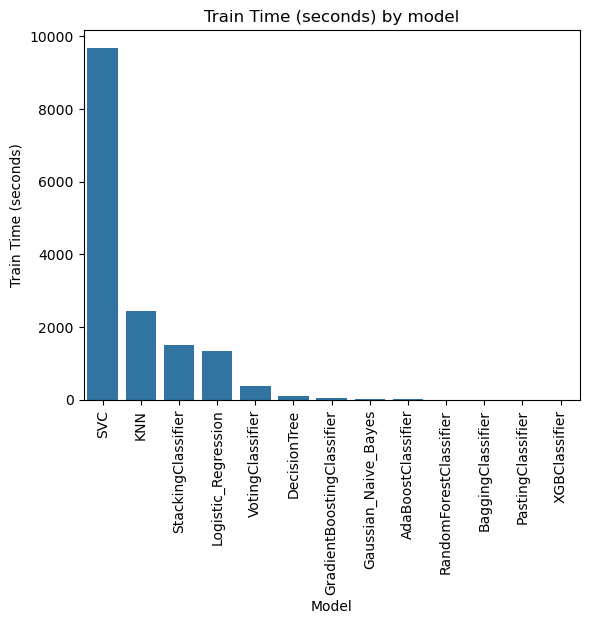

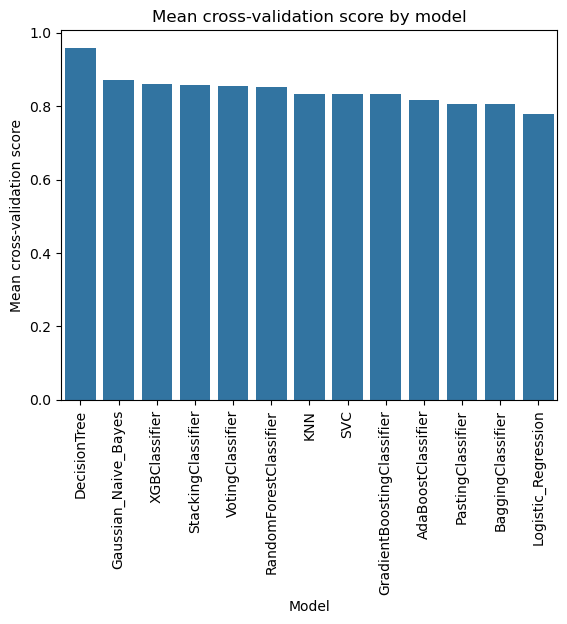

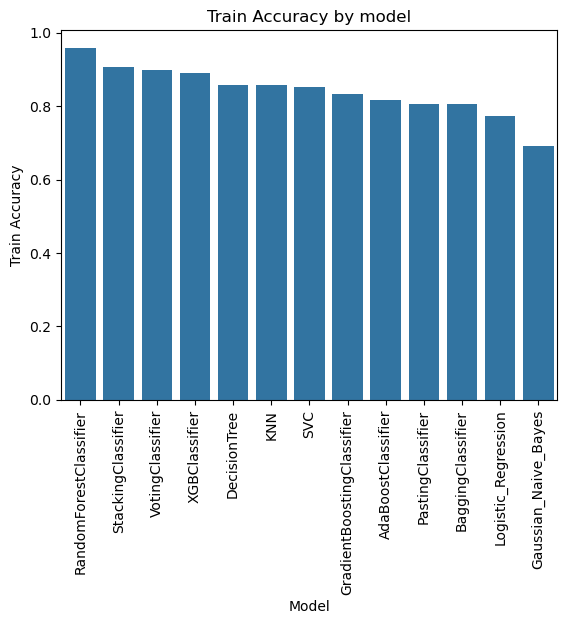

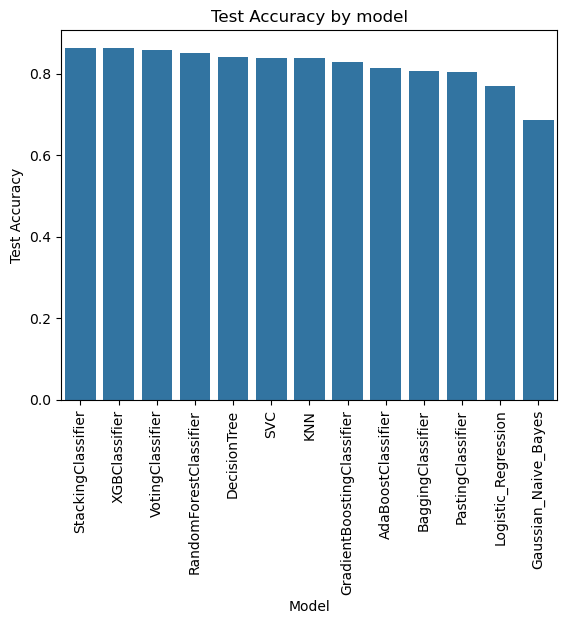

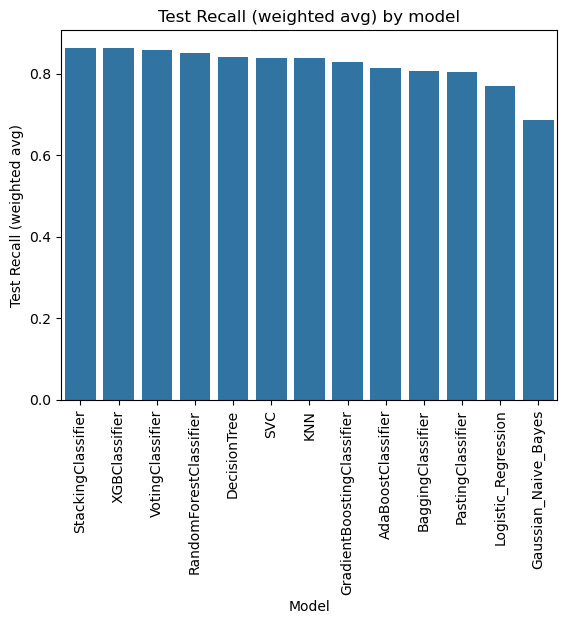

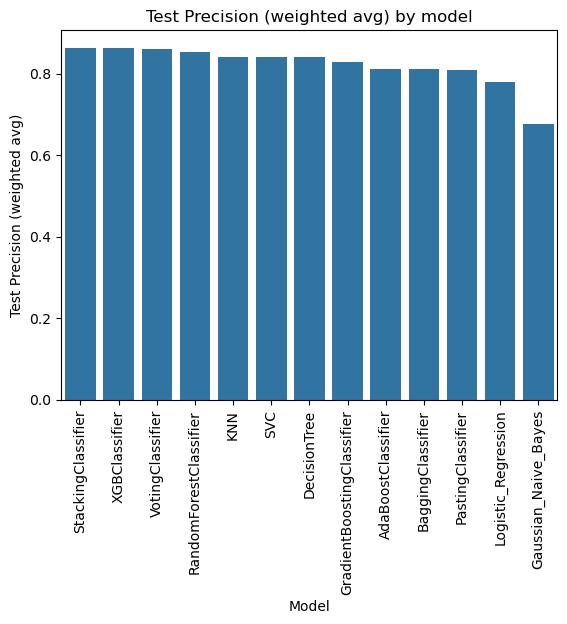

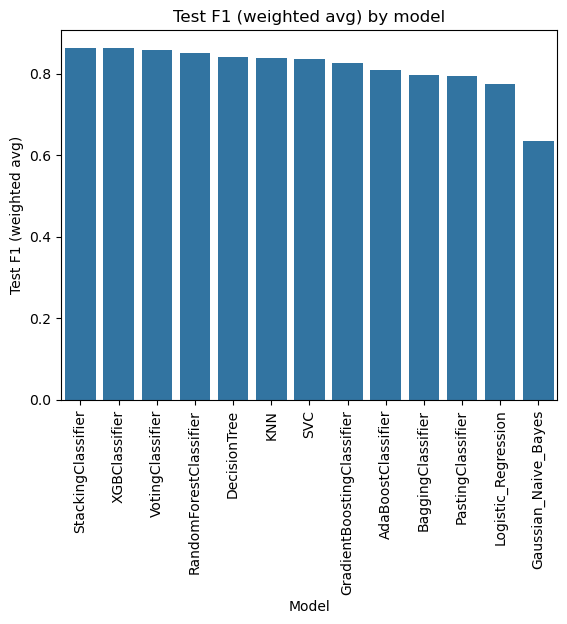

In [6]:
# We plot the Classification models results
results_classification_df = results_classification_df.rename(columns = {'Train Time':'Train Time (seconds)', 'CV score':'Mean cross-validation score', 'Test Recall':'Test Recall (weighted avg)',
                                                      'Test Precision':'Test Precision (weighted avg)', 'Test F1':'Test F1 (weighted avg)'})
list_ylabel = ['Train Time (seconds)', 'Mean cross-validation score', 'Train Accuracy', 'Test Accuracy', 'Test Recall (weighted avg)','Test Precision (weighted avg)','Test F1 (weighted avg)']

for ylabel in list_ylabel:
    df_plot = results_classification_df.sort_values(by=ylabel, ascending=False)
    
    sns.barplot(x='Model', y=ylabel, data=df_plot).tick_params(axis='x', labelrotation=90)
    # Customize ticks
    plt.title(ylabel + ' by model')
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    # Save figure to PNG file
    plt.savefig('images/Model_improvement/Classification models results - ' + ylabel + ' by model.png', bbox_inches='tight')
    plt.show()

In [59]:
results_final_df.to_csv('results/results_final.csv', index=False)

From the above results we can see that:
- the fastest model to train are the XGB Classifier, Pasting Classifier, Bagging Classifier, Random Forest Classifier, AdaBoost Classifier, Gaussian Naive Bayes and Gradient Boosting Classifier which take less than a minute. The slowest models to train is the Support Vector Classifier which takes more than 2,5 hours
- the model with the highest mean cross-validation score is the Decision Tree with a mean cross-validation score close to 0.96
- the model with the highest train accuracy is the Random Forest Classifier with a train accuracy close to 0.96
- the models with the best test accuracy, recall, precision and F1 score (weighted average) are the Stacking Classifier and XGB Classifier with all those metrics above 0.86
- the model with the worst train accuracy, test accuracy, test recall, test precision and test F1 score (weighted average) is the Gaussian Naive Bayes with all those metrics under 0.7
- all the models have better performance metrics than the baseline classification model except the Gaussian Naive Bayes model

#### 2. Comparison of Feature Importance across the 2 best classification models

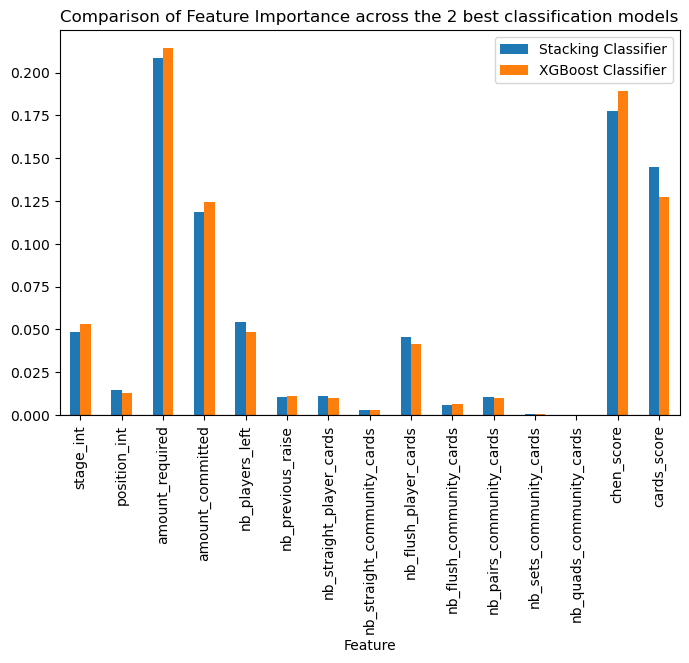

In [4]:
# For each model, we load the one with the best overall scoring metrics
stack_clf = joblib.load('models/StackingClassifier_GradientBoostingClassifier_6.pkl')
xgb_clf = joblib.load('models/XGBClassifier.pkl')

features = ['stage_int', 'position_int', 'amount_required', 'amount_committed', 'nb_players_left', 'nb_previous_raise', 
        'nb_straight_player_cards', 'nb_straight_community_cards', 'nb_flush_player_cards', 'nb_flush_community_cards', 'nb_pairs_community_cards', 'nb_sets_community_cards', 'nb_quads_community_cards',
        'chen_score', 'cards_score']

coeffs = pd.DataFrame({
  'Feature': features,
  'Stacking Classifier': permutation_importance(stack_clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1).importances_mean,
  'XGBoost Classifier': permutation_importance(xgb_clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1).importances_mean,
})

coeffs.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Comparison of Feature Importance across the 2 best classification models")
plt.axhline(0, color='black', linewidth=0.8)

# Save figure to PNG file
plt.savefig('images/Model_improvement/Comparison of Feature Importance across the 2 best classification models.png', bbox_inches='tight')
plt.show()

In the 2nd notebook about the Explanatory data analysis, for the classification model, we observed that the top 3 features were cards_score, amount_required and chen_score.
With the improved classification models, we observe that the top 3 features are still cards_score, amount_required and chen_score.

#### 3. Confusion matrix, ROC Curve and Classification report of the 2 best classification models

##### a. StackingClassifier model

In [4]:
stack_clf = joblib.load('models/StackingClassifier_GradientBoostingClassifier_6.pkl')
y_pred = stack_clf.predict(X_test)

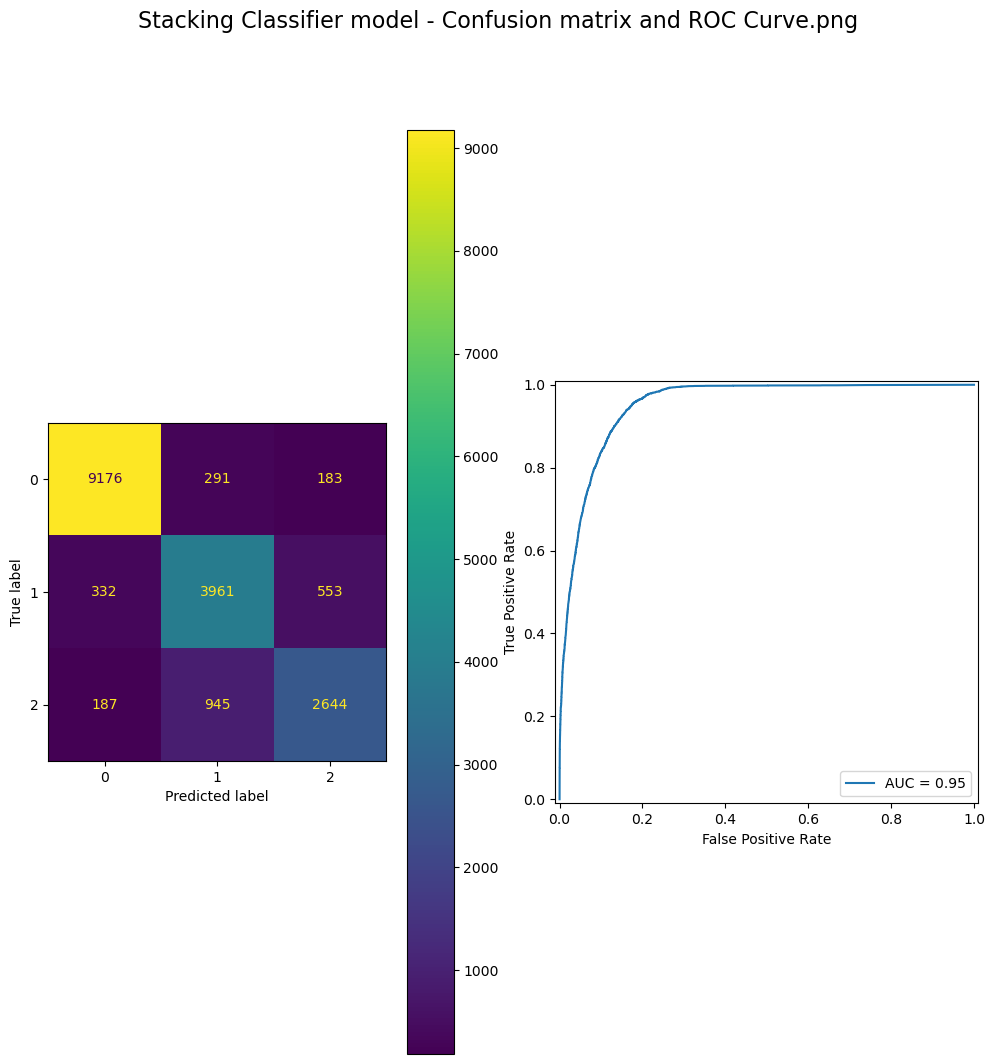

In [5]:
# Plot the Confusion matrix and ROC Curve of the Stacking Classifier model
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 12)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot(ax=ax[0])

# ROC Curve
y_score = stack_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)
roc_auc_value = skl_auc(fpr, tpr)

disp2 = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_value)
disp2.plot(ax=ax[1])

fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
auc = round(roc_auc_value, 2)
fig.suptitle('Stacking Classifier model - Confusion matrix and ROC Curve.png', fontsize=16)

# Save figure to PNG file
plt.savefig('images/Model_improvement/Stacking Classifier model - Confusion matrix and ROC Curve.png', bbox_inches='tight')

In [6]:
# Classification report
target_labels = ['Fold', 'Check/call', 'Raise']
print(classification_report(y_test, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

        Fold       0.95      0.95      0.95      9650
  Check/call       0.76      0.82      0.79      4846
       Raise       0.78      0.70      0.74      3776

    accuracy                           0.86     18272
   macro avg       0.83      0.82      0.83     18272
weighted avg       0.86      0.86      0.86     18272



##### b. XGB Classifier model

In [4]:
xgb_clf = joblib.load('models/XGBClassifier.pkl')
y_pred = xgb_clf.predict(X_test)

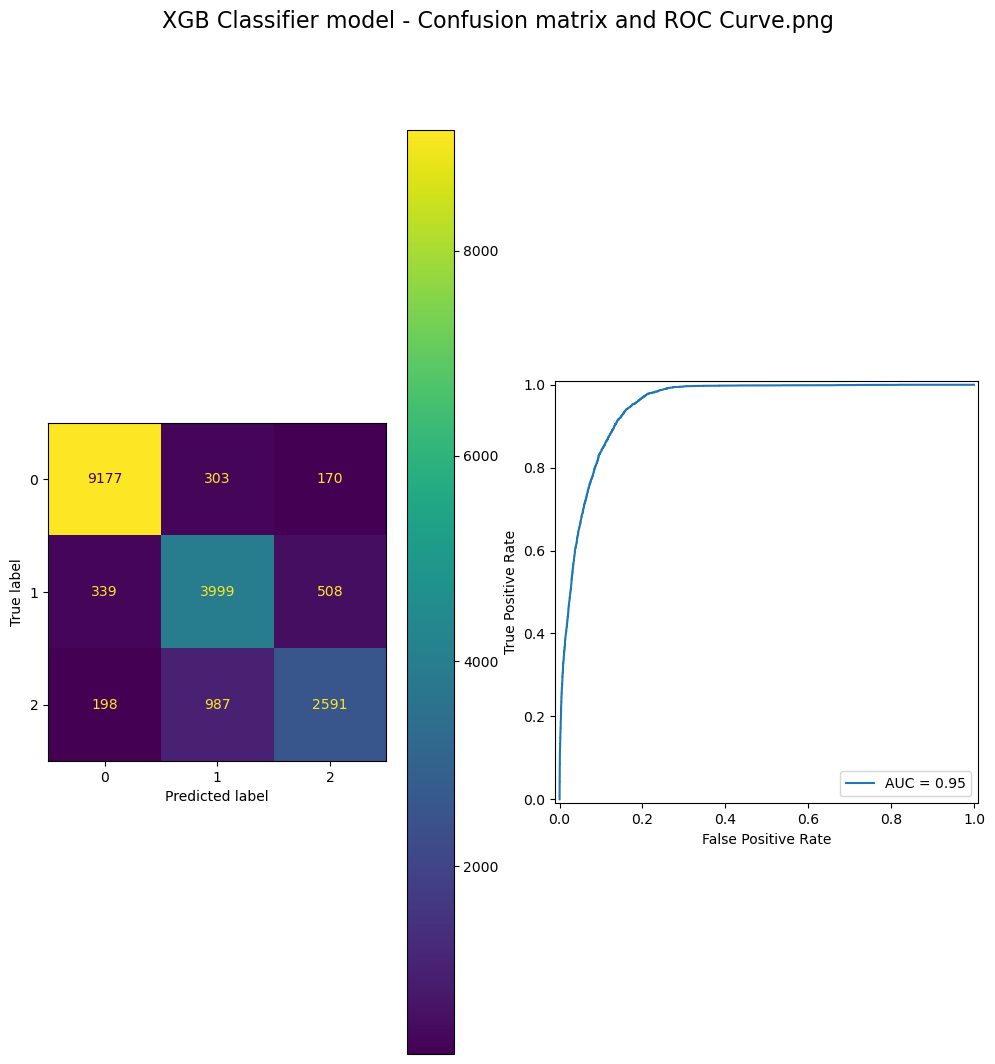

In [5]:
# Plot the Confusion matrix and ROC Curve of the XGB Classifier model
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 12)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot(ax=ax[0])

# ROC Curve
y_score = xgb_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)
roc_auc_value = skl_auc(fpr, tpr)

disp2 = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_value)
disp2.plot(ax=ax[1])

fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
auc = round(roc_auc_value, 2)
fig.suptitle('XGB Classifier model - Confusion matrix and ROC Curve.png', fontsize=16)

# Save figure to PNG file
plt.savefig('images/Model_improvement/XGB Classifier model - Confusion matrix and ROC Curve.png', bbox_inches='tight')

In [6]:
# Classification report
target_labels = ['Fold', 'Check/call', 'Raise']
print(classification_report(y_test, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

        Fold       0.94      0.95      0.95      9650
  Check/call       0.76      0.83      0.79      4846
       Raise       0.79      0.69      0.74      3776

    accuracy                           0.86     18272
   macro avg       0.83      0.82      0.82     18272
weighted avg       0.86      0.86      0.86     18272



#### 4. Performance metrics of the 2 best classifier models

##### a. Test Accuracy: 0.86
- **Interpretation**: The accuracy is the proportion of true results among the total number of cases examined. It is easy to interpret but can be misleading in imbalanced datasets, which is our case since we have an imbalanced dataset.
- **How good is it?**: Our model has 86% accuracy, this means that 86 out of 100 predictions are correct.

##### b. Test Recall (weighted avg): 0.86
- **Interpretation**: The recall is the proportion of actual positives that were correctly identified. It is useful when the cost of false negatives is high.
- **How good is it?**: Our model's recall is 0.86, this means that it was able to find 86% of all positive cases.

##### c. Test Precision (weighted avg): 0.86
- **Interpretation**: The precision is the proportion of positive identifications that were actually correct. It is useful when the cost of false positives is high.
- **How good is it?**: Our model's precision is 0.86, this means that 86% of the actions the model identified as positive cases are actual positive cases.

##### d. Test F1 score (weighted avg): 0.86
- **Interpretation**: The F1 is the harmonic mean of precision and recall. It is useful for balancing precision and recall and for dealing with imbalanced datasets. It is not interpretable as a statistical measure of the samples.
- **How good is it?**: Our F1 score of 0.86 indicates that the model is fairly good at identifying positive cases without labeling too many false positives or missing too many actual positives. This score is generally considered quite good for most classification tasks. 

##### e. ROC AUC: 0.95
- **Interpretation**: The ROC AUC is the area under the curve when plotting true positive rate (sensitivity) against the false positive rate (1-specificity). It handles both balanced and imbalanced datasets. It is less interpretable as it summarizes the model’s performance across all classification thresholds.
- **How good is it?**: An AUC of 0.95 means that there is 95% chance that the model will be able to distinguish between positive class and negative class.

## Improvement of the regression model to predict the amount to raise
In the previous notebook, we created a baseline regression model, which has the following performance metrics:
- test mean absolute error: 451.8923306791355
- test root mean squared error: 947.0337285006657
- test R2 score: 0.31585732483848805


We will try to improve the baseline regression model, by finding new models which have lower test mean absolute error, test root mean squared error and higher test R2 score.
We will be looking for new models using the Grid Search hyperparameters. We will also make a research for the best models according to each of the following scoring methods: neg_mean_absolute_error, neg_root_mean_squared_error, r2

In [4]:
# We need to filter the Dataset to select only the rows of data which have already been classified as action : Raise
df_r = df[(df['action'] == 'R')]
df_r.head()

,index,game_id,turn_id,player_id,player_name,stage,sub_stage,stage_int,position_int,position_code_1,...,nb_straight_player_cards,nb_straight_community_cards,nb_flush_player_cards,nb_flush_community_cards,chen_score,cards_score,pct_score,nb_pairs_community_cards,nb_sets_community_cards,nb_quads_community_cards
1,1,100_0,2,p4,MrPink,preflop,1,1,4,MP,...,2,0,2,0,7.0,6678,-0.0210,0,0,0
10,10,100_0,55,p1,MrBlue,river,1,10,1,SB,...,3,3,3,2,9.0,2768,0.0310,1,0,0
12,12,100_1,1,p3,MrPink,preflop,1,1,3,UTG,...,2,0,1,0,8.0,6881,0.0495,0,0,0
19,19,100_1,21,p3,MrPink,flop,1,4,3,UTG,...,4,3,3,2,8.0,6799,0.0495,0,0,0
22,22,100_1,39,p3,MrPink,turn,1,7,3,UTG,...,4,3,4,3,8.0,6799,0.0495,0,0,0


In [5]:
# With the data prepared, we split it again into a train and test set.
X = df_r[['stage_int', 'position_int', 'amount_required', 'amount_committed', 'nb_players_left', 'nb_previous_raise', 
        'nb_straight_player_cards', 'nb_straight_community_cards', 'nb_flush_player_cards', 'nb_flush_community_cards', 'nb_pairs_community_cards', 'nb_sets_community_cards', 'nb_quads_community_cards',
        'chen_score', 'cards_score']]
y = df_r['amount_raised']

# Divide the dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression Model with polynomial features

In [6]:
# Model: Linear Regression
results_linear_regression_df = pd.DataFrame()
for k in range(1,5):
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('poly', PolynomialFeatures(degree = k)),
        ('reg', LinearRegression())   
    ])
    start = time.time()
    pipelined_model.fit(X_train, y_train)
    end = time.time()
    
    # Evaluate the model
    y_pred = pipelined_model.predict(X_test)

    # saving the model
    joblib.dump(pipelined_model, 'models/LinearRegression_' + str(k) + '.pkl')
    
    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    cv_score = cross_val_score(pipelined_model, X_train, y_train, cv=5).mean()
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)
    
    results_df = pd.DataFrame({'Model': ['Linear regression'],
              'Performance metric' : ['none'],  
              'Train Time' : [fit_time],
              'Parameters' : [{'polynomial_degree': k}],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_linear_regression_df, results_df]
    results_linear_regression_df = pd.concat(frames)
results_linear_regression_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Linear regression,none,0.064856,{'polynomial_degree': 1},7.016708e-01,2.528054e+02,6.604511e+02,6.672661e-01
0,Linear regression,none,0.149864,{'polynomial_degree': 2},-5.296819e+09,2.193179e+02,5.870249e+02,7.371374e-01
0,Linear regression,none,0.647568,{'polynomial_degree': 3},-1.599792e+17,3.221350e+07,6.101086e+08,-2.839423e+11
0,Linear regression,none,10.435046,{'polynomial_degree': 4},-9.905341e+12,2.283415e+06,4.789408e+07,-1.749764e+09


Regarding the Linear Regression model:

- the train time is less than 11 seconds.
- the performance when the polynomial degree is 1 or 2 is better than the baseline regression model
- the Linear Regression model which has the best mean cross-validation score is the one for the polynomial degree 1. The score for the other polynomial degrees are too low and seem to indicate that the model is performing poorly
- the Linear Regression model which has the lowest test mean absolute error and test root mean squared error is the one for the polynomial degree 2
- the Linear Regression model which has the highest test R2 score is the one for the polynomial degree 2
- the best Linear Regression model seems to be the one for the polynomial degree 1. It doesn't have the lowest test mean absolute error and test root mean squared error and the highest test R2 score. However, it has the best mean cross-validation score which indicates the model is not performing poorly

In [7]:
results_linear_regression_df.to_csv('results/results_linear_regression.csv', index=False)

### Ridge Regression Model with polynomial features

In [6]:
# Model: Ridge Regression
results_ridge_df = pd.DataFrame()
list_scoring_method = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
for scoring_method in list_scoring_method:
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('poly', PolynomialFeatures(degree = 2)),
        ('ridge', Ridge())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'ridge__alpha': 10**np.linspace(-5,5,10)
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/Ridge_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['Ridge'],
              'Performance metric' : [scoring_method],  
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_ridge_df, results_df]
    results_ridge_df = pd.concat(frames)
results_ridge_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Ridge,neg_mean_absolute_error,2.006071,{'ridge__alpha': 46.41588833612782},-221.847725,219.220914,590.104528,0.734372
0,Ridge,neg_root_mean_squared_error,2.138427,{'ridge__alpha': 3.593813663804626},-550.972449,219.276111,587.275846,0.736913
0,Ridge,r2,2.057405,{'ridge__alpha': 3.593813663804626},0.779107,219.276111,587.275846,0.736913


Regarding the Ridge Regression model:

- the train time is around 2 seconds.
- the performance is better than the baseline regression model
- only 2 different models were selected:
     - one for the neg_root_mean_squared_error and r2 performance metrics, which have the same GridsearchCV parameter. It has the highest test R2 score and the lowest test root mean squared error
     - one for the neg_mean_absolute_error performance metrics, which has a different GridsearchCV parameter. It has the lowest test mean absolute error
- the best Ridge Regression model seems to be the one for parameter alpha': 3.593813663804626, as it has the highest test R2 score and the lowest test root mean squared error

In [8]:
results_ridge_df.to_csv('results/results_ridge.csv', index=False)

### Lasso Regression Model with polynomial features

In [10]:
# Model: Lasso Regression
pipelined_model = Pipeline([
    ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
    ('poly', PolynomialFeatures(degree = 2)),
    ('lasso', Lasso(random_state = 42))
])
start = time.time()
pipelined_model.fit(X_train, y_train)
end = time.time()

# Evaluate the model
y_pred = pipelined_model.predict(X_test)

# saving the model
joblib.dump(pipelined_model, 'models/Lasso.pkl')

# Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
fit_time = end - start
cv_score = cross_val_score(pipelined_model, X_train, y_train, cv=5).mean()
Test_MAE = mean_absolute_error(y_test, y_pred)
Test_RMSE = root_mean_squared_error(y_test, y_pred)
Test_R2_Score = r2_score(y_test, y_pred)

results_lasso_df = pd.DataFrame({'Model': ['Lasso'],
          'Performance metric' : ['none'],  
          'Train Time' : [fit_time],
          'Parameters' : [{'random_state': 42}],
          'CV score' : [cv_score],
          'Test MAE' : [Test_MAE],
          'Test RMSE' : [Test_RMSE],
          'Test R2 Score' : [Test_R2_Score]
                      })
results_lasso_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Lasso,none,4.261827,{'random_state': 42},0.779751,214.094149,585.610832,0.738402


Regarding the Lasso Regression model:

- the train time is around 4 seconds.
- the performance is better than the baseline regression model

In [11]:
results_lasso_df.to_csv('results/results_lasso.csv', index=False)

### KNN Regressor Model

In [12]:
# Model: KNN Regressor
results_knn_regressor_df = pd.DataFrame()
list_scoring_method = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
for scoring_method in list_scoring_method:
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('knn', KNeighborsRegressor())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'knn__n_neighbors': range(1, 101, 1)
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/KNNRegressor_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['KNN regressor'],
              'Performance metric' : [scoring_method],  
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_knn_regressor_df, results_df]
    results_knn_regressor_df = pd.concat(frames)
results_knn_regressor_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,KNN regressor,neg_mean_absolute_error,147.642880,{'knn__n_neighbors': 12},-186.460695,176.773072,557.252575,0.763125
0,KNN regressor,neg_root_mean_squared_error,162.628795,{'knn__n_neighbors': 7},-542.670877,174.634371,556.315080,0.763921
0,KNN regressor,r2,140.547104,{'knn__n_neighbors': 7},0.785292,174.634371,556.315080,0.763921


Regarding the KNN Regressor model:

- the train time is around 7 min 30 seconds.
- the performance is better than the baseline regression model
- only 2 different models were selected:
     - one for the neg_root_mean_squared_error and r2 performance metrics, which have the same GridsearchCV parameter: n_neighbors = 7. It has the lowest test mean absolute error and test root mean squared error, and the highest test R2 score
     - one for the neg_mean_absolute_error performance metrics, which has the GridsearchCV parameter: n_neighbors = 12
- the best KNN Regressor model seems to be the one for parameters n_neighbors = 7, as it has the lowest test mean absolute error and test root mean squared error, and the highest test R2 score

In [13]:
results_knn_regressor_df.to_csv('results/results_knn_regressor.csv', index=False)

### Stochastic Gradient Descent Regressor Model

In [14]:
# Model: Stochastic Gradient Descent Regressor
results_sgd_regressor_df = pd.DataFrame()
list_scoring_method = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
for scoring_method in list_scoring_method:
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('sgd', SGDRegressor())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'sgd__loss': ['squared_error', 'huber', 'epsilon_insensitive'],
        'sgd__penalty': ['l2', 'l1', 'elasticnet'],
        'sgd__alpha': [0.0001, 0.001],
        'sgd__max_iter': [1000],
        'sgd__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
        'sgd__eta0': [0.001, 0.01]
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/SGDRegressor_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['SGD regressor'],
              'Performance metric' : [scoring_method],  
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_sgd_regressor_df, results_df]
    results_sgd_regressor_df = pd.concat(frames)
results_sgd_regressor_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,SGD regressor,neg_mean_absolute_error,268.434383,"{'sgd__alpha': 0.001, 'sgd__eta0': 0.01, 'sgd_...",-224.368895,224.717230,695.409450,0.631110
0,SGD regressor,neg_root_mean_squared_error,280.919044,"{'sgd__alpha': 0.0001, 'sgd__eta0': 0.01, 'sgd...",-641.274981,252.072825,660.891634,0.666822
0,SGD regressor,r2,264.389561,"{'sgd__alpha': 0.0001, 'sgd__eta0': 0.001, 'sg...",0.701739,251.617123,660.740925,0.666974


Regarding the Stochastic Gradient Descent Regressor model:

- the train time is around 4 minutes 30 seconds.
- the performance is better than the baseline regression model
- the Stochastic Gradient Descent Regressor model which has the lowest test mean absolute error is the one for performance metric: neg_mean_absolute_error
- the Stochastic Gradient Descent Regressor model which has the lowest test root mean squared error is the one for performance metric: r2
- the Stochastic Gradient Descent Regressor model which has the highest test R2 score is the one for performance metric: r2
- the best Stochastic Gradient Descent Regressor model seems to be the one for performance metric: r2, as it has the lowest test root mean squared error and the highest test R2 score

In [15]:
results_sgd_regressor_df.to_csv('results/results_sgd_regressor.csv', index=False)

### Decision Tree Regressor Model

In [16]:
# Model: Decision Tree Regressor
results_dt_regressor_df = pd.DataFrame()
list_scoring_method = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
for scoring_method in list_scoring_method:
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('regressor', DecisionTreeRegressor())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'regressor__max_depth': [3, 5, 7, 10, 20, 30]
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/DecisionTreeRegressor_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['Decision Tree regressor'],
              'Performance metric' : [scoring_method],  
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_dt_regressor_df, results_df]
    results_dt_regressor_df = pd.concat(frames)
results_dt_regressor_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Decision Tree regressor,neg_mean_absolute_error,1.005048,{'regressor__max_depth': 10},-183.485597,173.366873,631.105270,0.696178
0,Decision Tree regressor,neg_root_mean_squared_error,1.027804,{'regressor__max_depth': 5},-559.866886,203.065241,567.998161,0.753901
0,Decision Tree regressor,r2,1.001972,{'regressor__max_depth': 5},0.770123,203.065241,567.998161,0.753901


Regarding the Decision Tree Regressor model:

- the train time is around 1 second.
- the performance is better than the baseline regression model
- only 2 different models were selected:
     - one for the neg_root_mean_squared_error and r2 performance metrics, which have the same GridsearchCV parameter: max_depth = 5. It has the lowest test root mean squared error and the highest test R2 score
     - one for the neg_mean_absolute_error performance metrics, which has the GridsearchCV parameter: max_depth = 10. It has the lowest test mean absolute error
- the best Decision Tree Regressor model seems to be the one for parameters max_depth = 5, as it has the lowest test root mean squared error and the highest test R2 score

In [17]:
results_dt_regressor_df.to_csv('results/results_dt_regressor.csv', index=False)

### Support Vector Regressor Model

In [18]:
# Model: Support Vector Regressor
results_sv_regressor_df = pd.DataFrame()
list_scoring_method = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
for scoring_method in list_scoring_method:
    pipelined_model = Pipeline([
        ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
        ('regressor', SVR())
    ])
    
    # GridSearchCV
    param_grid_values = {
        'regressor__C': [0.1, 1.0, 10.0], 
        'regressor__gamma': ['scale', 'auto']
    }
    model_finder = GridSearchCV(estimator = pipelined_model,
                                param_grid = param_grid_values,
                                scoring = scoring_method, 
                                cv=5
                               )
    
    start = time.time()
    model_finder.fit(X_train, y_train)
    end = time.time()
    best_model = model_finder.best_estimator_
    
    # Evaluate the model
    y_pred = best_model.predict(X_test)

    # saving the model
    joblib.dump(best_model, 'models/SVRegressor_' + scoring_method + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    params = model_finder.best_params_
    cv_score = model_finder.best_score_
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['SV regressor'],
              'Performance metric' : [scoring_method],  
              'Train Time' : [fit_time],
              'Parameters' : [params],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                          })
    frames = [results_sv_regressor_df, results_df]
    results_sv_regressor_df = pd.concat(frames)
results_sv_regressor_df.head()

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,SV regressor,neg_mean_absolute_error,177.635688,"{'regressor__C': 10.0, 'regressor__gamma': 'au...",-285.738280,267.196747,904.568946,0.375835
0,SV regressor,neg_root_mean_squared_error,176.851011,"{'regressor__C': 10.0, 'regressor__gamma': 'au...",-953.583908,267.196747,904.568946,0.375835
0,SV regressor,r2,178.478696,"{'regressor__C': 10.0, 'regressor__gamma': 'au...",0.341881,267.196747,904.568946,0.375835


Regarding the Support Vector Regressor model:

- the train time is around 3 minutes.
- the performance is better than the baseline regression model
- only 1 different model was selected. All above 3 results have the same GridsearchCV parameters: C=10, gamma = auto

In [19]:
results_sv_regressor_df.to_csv('results/results_sv_regressor.csv', index=False)

### Voting Regressor Model

In [14]:
# Instantiate the individual models
# For each model, we load the one with the best overall scoring metrics
knn_reg = joblib.load('models/KNNRegressor_r2.pkl')
dt_reg = joblib.load('models/DecisionTreeRegressor_r2.pkl')
lasso_reg = joblib.load('models/Lasso.pkl')
ridge_reg = joblib.load('models/Ridge_r2.pkl')
lin_reg = joblib.load('models/LinearRegression_1.pkl')
sgd_reg = joblib.load('models/SGDRegressor_r2.pkl')
sv_reg = joblib.load('models/SVRegressor_r2.pkl')

results_voting_regressor_df = pd.DataFrame()
list_estimators = [
    [('knn', knn_reg), ('dt', dt_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg), ('sgd', sgd_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg), ('sgd', sgd_reg), ('sv', sv_reg)]
]
for estimator in list_estimators:
    
    # Create the voting regressor
    voting_reg = VotingRegressor(
        estimators = estimator
    )
    
    # Fit the model
    start = time.time()
    voting_reg.fit(X_train, y_train)
    end = time.time()

    # Evaluate the model
    y_pred = voting_reg.predict(X_test)
    
    # saving the model
    joblib.dump(voting_reg, 'models/VotingRegressor_' + str(len(estimator)) + '.pkl')

    # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
    fit_time = end - start
    cv_score = cross_val_score(voting_reg, X_train, y_train, cv=5).mean()
    Test_MAE = mean_absolute_error(y_test, y_pred)
    Test_RMSE = root_mean_squared_error(y_test, y_pred)
    Test_R2_Score = r2_score(y_test, y_pred)

    results_df = pd.DataFrame({'Model': ['Voting regressor'],
              'Performance metric' : ['none'],  
              'Train Time' : [fit_time],
              'Parameters' : [{'n_models': str(len(estimator))}],
              'CV score' : [cv_score],
              'Test MAE' : [Test_MAE],
              'Test RMSE' : [Test_RMSE],
              'Test R2 Score' : [Test_R2_Score]
                      })
    frames = [results_voting_regressor_df, results_df]
    results_voting_regressor_df = pd.concat(frames)
results_voting_regressor_df.head(10)

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Voting regressor,none,0.056647,{'n_models': '2'},0.805212,172.261239,539.547425,0.777938
0,Voting regressor,none,6.088841,{'n_models': '3'},0.811834,174.241108,533.978501,0.782498
0,Voting regressor,none,6.935386,{'n_models': '4'},0.809484,181.084487,539.214000,0.778212
0,Voting regressor,none,6.700801,{'n_models': '5'},0.802099,186.955964,551.322578,0.768139
0,Voting regressor,none,6.564825,{'n_models': '6'},0.793090,194.175966,563.310392,0.757947
0,Voting regressor,none,12.570151,{'n_models': '7'},0.778721,194.798176,576.502166,0.746477


Regarding the Voting Regressor model:

- the train time is less than 13 seconds.
- the performance is better than the baseline regression model
- the Voting Regressor model which has the highest mean cross-validation score is the one which has 3 estimators models
- the Voting Regressor model which has the lowest test mean absolute error is the one which has 2 estimators models
- the Voting Regressor model which has the lowest test root mean squared error is the one which has 3 estimators models
- the Voting Regressor model which has the highest test R2 score is the one which has 3 estimators models
- the best Voting Regressor model is the one which has 3 estimators models because it has the highest mean cross-validation score, the lowest test root mean squared error, and the highest test R2 score

In [15]:
results_voting_regressor_df.to_csv('results/results_voting_regressor.csv', index=False)

### Stacking Regressor Model

In [16]:
# Instantiate the individual models
# For each model, we load the one with the best overall scoring metrics
knn_reg = joblib.load('models/KNNRegressor_r2.pkl')
dt_reg = joblib.load('models/DecisionTreeRegressor_r2.pkl')
lasso_reg = joblib.load('models/Lasso.pkl')
ridge_reg = joblib.load('models/Ridge_r2.pkl')
lin_reg = joblib.load('models/LinearRegression_1.pkl')
sgd_reg = joblib.load('models/SGDRegressor_r2.pkl')
sv_reg = joblib.load('models/SVRegressor_r2.pkl')

results_stacking_regressor_df = pd.DataFrame()
list_estimators = [
    [('knn', knn_reg), ('dt', dt_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg), ('sgd', sgd_reg)],
    [('knn', knn_reg), ('dt', dt_reg), ('lasso', lasso_reg), ('ridge', ridge_reg), ('lin', lin_reg), ('sgd', sgd_reg), ('sv', sv_reg)]
]
dict_final_estimators = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor() 
}
for estimator in list_estimators:
    for final_estimator_key, final_estimator_value in dict_final_estimators.items():

        # Stacking regressor
        stack_reg = StackingRegressor(
            estimators=estimator,
            final_estimator=final_estimator_value
        )
        
        # Fit the model
        start = time.time()
        stack_reg.fit(X_train, y_train)
        end = time.time()
        
        # Evaluate the model
        y_pred = stack_reg.predict(X_test)
        
        # saving the model
        joblib.dump(stack_reg, 'models/StackingRegressor_' + final_estimator_key + '_' + str(len(estimator)) + '.pkl')
        
        # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
        fit_time = end - start
        cv_score = cross_val_score(stack_reg, X_train, y_train, cv=5).mean()
        Test_MAE = mean_absolute_error(y_test, y_pred)
        Test_RMSE = root_mean_squared_error(y_test, y_pred)
        Test_R2_Score = r2_score(y_test, y_pred)
    
        results_df = pd.DataFrame({'Model': ['Stacking regressor'],
                  'Performance metric' : ['none'],  
                  'Train Time' : [fit_time],
                  'Parameters' : [{'final_estimator': final_estimator_key, 'n_models': str(len(estimator))}],
                  'CV score' : [cv_score],
                  'Test MAE' : [Test_MAE],
                  'Test RMSE' : [Test_RMSE],
                  'Test R2 Score' : [Test_R2_Score]
                          })
        frames = [results_stacking_regressor_df, results_df]
        results_stacking_regressor_df = pd.concat(frames)
results_stacking_regressor_df.head(100)

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Stacking regressor,none,1.088566,"{'final_estimator': 'LinearRegression', 'n_mod...",0.805215,172.525582,534.400830,0.782154
0,Stacking regressor,none,1.038029,"{'final_estimator': 'Ridge', 'n_models': '2'}",0.804876,172.517444,534.457886,0.782107
0,Stacking regressor,none,1.082979,"{'final_estimator': 'Lasso', 'n_models': '2'}",0.805142,172.433084,534.387227,0.782165
0,Stacking regressor,none,1.057240,"{'final_estimator': 'KNeighborsRegressor', 'n_...",0.772817,189.792639,558.244986,0.762280
0,Stacking regressor,none,1.080066,"{'final_estimator': 'DecisionTreeRegressor', '...",0.639361,237.350142,723.982797,0.600173
0,Stacking regressor,none,30.561135,"{'final_estimator': 'LinearRegression', 'n_mod...",0.812035,172.141417,529.203063,0.786371
0,Stacking regressor,none,33.410512,"{'final_estimator': 'Ridge', 'n_models': '3'}",0.811707,172.212521,529.195911,0.786377
0,Stacking regressor,none,29.606648,"{'final_estimator': 'Lasso', 'n_models': '3'}",0.812105,172.137918,529.156039,0.786409
0,Stacking regressor,none,30.194388,"{'final_estimator': 'KNeighborsRegressor', 'n_...",0.781083,179.602544,552.191105,0.767408
0,Stacking regressor,none,30.408108,"{'final_estimator': 'DecisionTreeRegressor', '...",0.607066,231.757175,709.554173,0.615951


In [17]:
results_stacking_regressor_df.to_csv('results/results_stacking_regressor.csv', index=False)

Regarding the Stacking Regressor model:

- the train time is less than 72 seconds.
- the performance is better than the baseline regression model
- the Stacking Regressor model which has the highest mean cross-validation score is the one for the final estimator: LinearRegression and which has 6 estimators models
- the Stacking Regressor model which has the lowest test mean absolute error is the one for the final estimator: Lasso and which has 3 estimators models
- the Stacking Regressor model which has the lowest test root mean squared error is the one for the final estimator: Ridge and which has 7 estimators models
- the Stacking Regressor model which has the highest test R2 score is the one for the final estimator: Ridge and which has 7 estimators models
- the best Stacking Regressor model is the one for the final estimator: Ridge and which has 7 estimators models because it has the lowest test root mean squared error and the highest test R2 score

### Tests with Sequential Feature Selection to improve the model

We will make some tests with one of the top 3 regression model to see if the features selection could improve the model's performance. We will choose the KNN Regressor model as it is in the top 3 regression model. As in general, the scoring method which overall provided the best models seems to be the r2 scoring method, we will use the scoring method r2 for this test

In [6]:
# Model: KNN Regressor
test_knn_regressor_df = pd.DataFrame()
list_features_to_select = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
list_direction = ['forward', 'backward']
for direction_item in list_direction:
    for n_features in list_features_to_select:
        pipelined_model = Pipeline([
            ('col_transformer',  make_column_transformer((OneHotEncoder(drop = 'first'), make_column_selector(dtype_include=object)), remainder = StandardScaler())),
            ('column_selector', SequentialFeatureSelector(LinearRegression(), n_features_to_select=n_features, direction = direction_item)),
            ('knn', KNeighborsRegressor())
        ])
        
        # GridSearchCV
        param_grid_values = {
            'knn__n_neighbors': range(1, 21, 1)
        }
        model_finder = GridSearchCV(estimator = pipelined_model,
                                    param_grid = param_grid_values,
                                    scoring = 'r2', 
                                    cv=2
                                   )
        
        start = time.time()
        model_finder.fit(X_train, y_train)
        end = time.time()
        best_model = model_finder.best_estimator_
        
        # Evaluate the model
        y_pred = best_model.predict(X_test)
    
        # Calculate the train time, best parameters, best CV score, test MAE, Test RMSE, test R2 Score
        fit_time = end - start
        params = model_finder.best_params_
        cv_score = model_finder.best_score_
        Test_MAE = mean_absolute_error(y_test, y_pred)
        Test_RMSE = root_mean_squared_error(y_test, y_pred)
        Test_R2_Score = r2_score(y_test, y_pred)
    
        results_df = pd.DataFrame({'Model': ['KNN regressor'],
                  'Performance metric' : ['r2'],  
                  'Train Time' : [fit_time],
                  'Parameters' : [params],
                  'N features' : [n_features],
                  'Direction' : [direction_item],
                  'CV score' : [cv_score],
                  'Test MAE' : [Test_MAE],
                  'Test RMSE' : [Test_RMSE],
                  'Test R2 Score' : [Test_R2_Score]
                              })
        frames = [test_knn_regressor_df, results_df]
        test_knn_regressor_df = pd.concat(frames)
test_knn_regressor_df.head()

,Model,Performance metric,Train Time,Parameters,N features,Direction,CV score,Test MAE,Test RMSE,Test R2 Score
0,KNN regressor,r2,7.679064,{'knn__n_neighbors': 20},1,forward,0.412468,394.635548,892.009341,0.393048
0,KNN regressor,r2,11.698334,{'knn__n_neighbors': 18},2,forward,0.768599,185.072861,565.339314,0.756200
0,KNN regressor,r2,16.304180,{'knn__n_neighbors': 17},3,forward,0.817372,166.494579,536.248333,0.780645
0,KNN regressor,r2,23.298434,{'knn__n_neighbors': 20},4,forward,0.812734,166.845277,539.958413,0.777599
0,KNN regressor,r2,30.316585,{'knn__n_neighbors': 19},5,forward,0.813465,165.466548,531.074382,0.784857


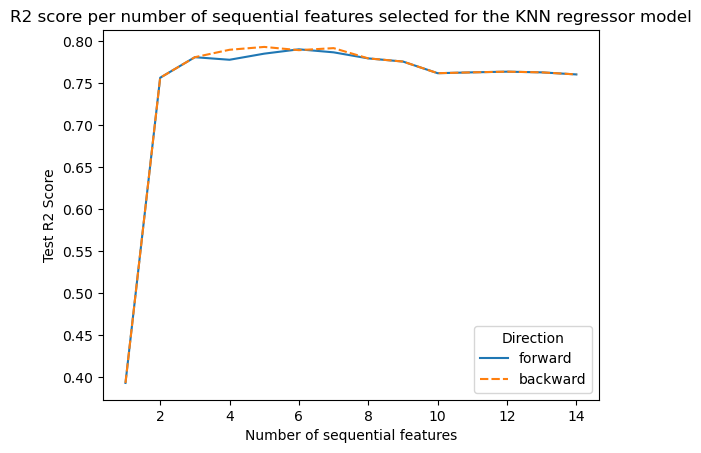

In [14]:
# Plot the tests with Sequential Feature Selection to improve the KNN regressor model
sns.lineplot(x='N features', y='Test R2 Score', hue='Direction', style='Direction', data=test_knn_regressor_df)

# Customize ticks
plt.title('R2 score per number of sequential features selected for the KNN regressor model')
plt.xlabel('Number of sequential features')
# Save figure to PNG file
plt.savefig('images/Model_improvement/R2 score per number of sequential features selected for the KNN regressor model.png', bbox_inches='tight')
plt.show()

We noted that the test R2 score is the highest for 5 sequential features selected and direction backward. The test R2 score is around 0.793. It beats the R2 score for the Stacking regressor model which was previously the highest at 0.788

In [7]:
test_knn_regressor_df.to_csv('results/test_knn_regressor.csv', index=False)

### Regression models results with 15 features

In [19]:
results_linear_regression_df = pd.read_csv('results/results_linear_regression.csv')
results_ridge_df = pd.read_csv('results/results_ridge.csv')
results_lasso_df = pd.read_csv('results/results_lasso.csv')
results_knn_regressor_df = pd.read_csv('results/results_knn_regressor.csv')
results_sgd_regressor_df = pd.read_csv('results/results_sgd_regressor.csv')
results_dt_regressor_df = pd.read_csv('results/results_dt_regressor.csv')
results_sv_regressor_df = pd.read_csv('results/results_sv_regressor.csv')
results_voting_regressor_df = pd.read_csv('results/results_voting_regressor.csv')
results_stacking_regressor_df = pd.read_csv('results/results_stacking_regressor.csv')

In [20]:
results_regression_df = pd.concat([
                              results_linear_regression_df.loc[(results_linear_regression_df['Parameters'] == "{'polynomial_degree': 1}")], 
                              results_ridge_df.loc[(results_ridge_df['Performance metric'] == 'r2')], 
                              results_lasso_df, 
                              results_knn_regressor_df.loc[(results_knn_regressor_df['Performance metric'] == 'r2')], 
                              results_sgd_regressor_df.loc[(results_sgd_regressor_df['Performance metric'] == 'r2')], 
                              results_dt_regressor_df.loc[(results_dt_regressor_df['Performance metric'] == 'r2')], 
                              results_sv_regressor_df.loc[(results_sv_regressor_df['Performance metric'] == 'r2')], 
                              results_voting_regressor_df.loc[(results_voting_regressor_df['Parameters'] == "{'n_models': '3'}")], 
                              results_stacking_regressor_df.loc[(results_stacking_regressor_df['Parameters'] == "{'final_estimator': 'Ridge', 'n_models': '7'}")]
                             ]).reset_index().drop(columns=['index'])
results_regression_df.head(100)

,Model,Performance metric,Train Time,Parameters,CV score,Test MAE,Test RMSE,Test R2 Score
0,Linear regression,none,0.064856,{'polynomial_degree': 1},0.701671,252.805408,660.451060,0.667266
1,Ridge,r2,2.057405,{'ridge__alpha': 3.593813663804626},0.779107,219.276111,587.275846,0.736913
2,Lasso,none,4.261827,{'random_state': 42},0.779751,214.094149,585.610832,0.738402
3,KNN regressor,r2,140.547104,{'knn__n_neighbors': 7},0.785292,174.634371,556.315080,0.763921
4,SGD regressor,r2,264.389561,"{'sgd__alpha': 0.0001, 'sgd__eta0': 0.001, 'sg...",0.701739,251.617123,660.740925,0.666974
5,Decision Tree regressor,r2,1.001972,{'regressor__max_depth': 5},0.770123,203.065241,567.998161,0.753901
6,SV regressor,r2,178.478696,"{'regressor__C': 10.0, 'regressor__gamma': 'au...",0.341881,267.196747,904.568946,0.375835
7,Voting regressor,none,6.088841,{'n_models': '3'},0.811834,174.241108,533.978501,0.782498
8,Stacking regressor,none,62.307324,"{'final_estimator': 'Ridge', 'n_models': '7'}",0.812734,172.300412,526.328717,0.788685


In [21]:
results_regression_df.to_csv('results/results_regression.csv', index=False)

#### 1. Comparison of Feature Importance across the 2 best regression models

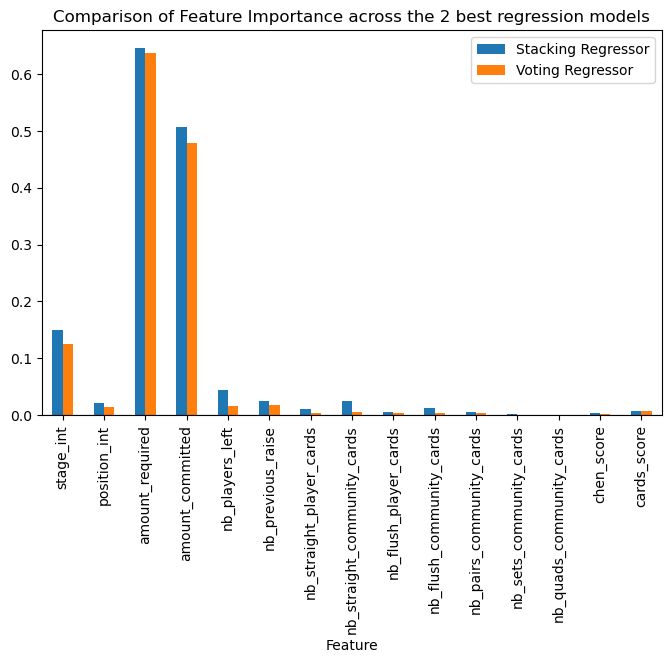

In [11]:
# Comparison of Feature Importance across the 2 best regression models
# For each model, we load the one with the best overall scoring metrics
stack_reg = joblib.load('models/StackingRegressor_Ridge_7.pkl')
voting_reg = joblib.load('models/VotingRegressor_3.pkl')

features = ['stage_int', 'position_int', 'amount_required', 'amount_committed', 'nb_players_left', 'nb_previous_raise', 
        'nb_straight_player_cards', 'nb_straight_community_cards', 'nb_flush_player_cards', 'nb_flush_community_cards', 'nb_pairs_community_cards', 'nb_sets_community_cards', 'nb_quads_community_cards',
        'chen_score', 'cards_score']

coeffs = pd.DataFrame({
  'Feature': features,
  'Stacking Regressor': permutation_importance(stack_reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1).importances_mean,
  'Voting Regressor': permutation_importance(voting_reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1).importances_mean
})

coeffs.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Comparison of Feature Importance across the 2 best regression models")
plt.axhline(0, color='black', linewidth=0.8)

# Save figure to PNG file
plt.savefig('images/Model_improvement/Comparison of Feature Importance across the 2 best regression models.png', bbox_inches='tight')
plt.show()

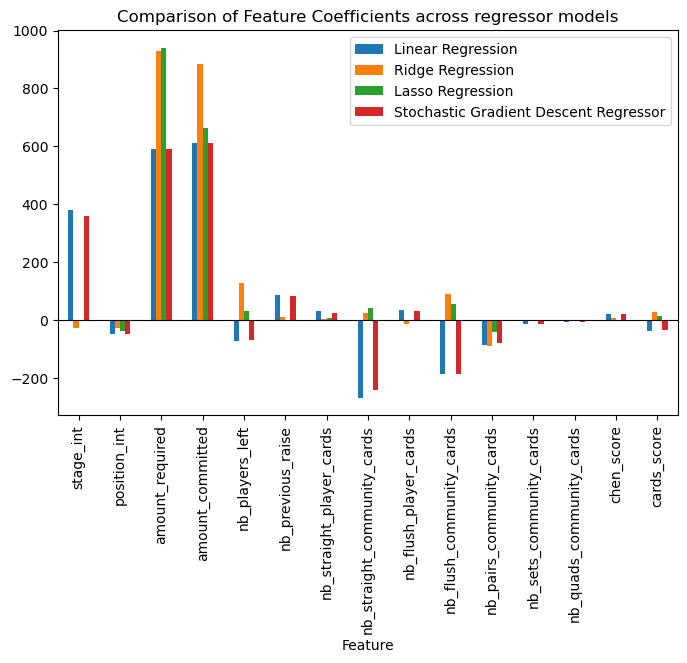

In [10]:
# Comparison of Feature Coefficients across regressor models
# For each model, we load the one with the best overall scoring metrics
lasso_reg = joblib.load('models/Lasso.pkl')
ridge_reg = joblib.load('models/Ridge_r2.pkl')
lin_reg = joblib.load('models/LinearRegression_1.pkl')
sgd_reg = joblib.load('models/SGDRegressor_r2.pkl')

features = ['stage_int', 'position_int', 'amount_required', 'amount_committed', 'nb_players_left', 'nb_previous_raise', 
        'nb_straight_player_cards', 'nb_straight_community_cards', 'nb_flush_player_cards', 'nb_flush_community_cards', 'nb_pairs_community_cards', 'nb_sets_community_cards', 'nb_quads_community_cards',
        'chen_score', 'cards_score']

coeffs = pd.DataFrame({
  'Feature': features,
  'Linear Regression': lin_reg.named_steps['reg'].coef_[1:],
  'Ridge Regression': ridge_reg.named_steps['ridge'].coef_[1:16],
  'Lasso Regression': lasso_reg.named_steps['lasso'].coef_[1:16],
  'Stochastic Gradient Descent Regressor': sgd_reg.named_steps['sgd'].coef_
})

coeffs.set_index("Feature").plot(kind="bar", figsize=(8,5))
plt.title("Comparison of Feature Coefficients across regressor models")
plt.axhline(0, color='black', linewidth=0.8)

# Save figure to PNG file
plt.savefig('images/Model_improvement/Comparison of Feature Coefficients across regressor models.png', bbox_inches='tight')
plt.show()

For the classification models, we observed that the top 3 features were cards_score, amount_required and chen_score. 
With the regression models, we observe that:
- the top 3 features are amount_required, amount_committed and stage_int
- for positive coefficients, the top features are also amount_required, amount_committed, and stage_int. An increase in the feature value increases the target variable: amount_raised. This means that players will bet more if the previous players already betted an important amount or if they already committed a great amount in the pot or as we advance further into the game's stages
- for negative coefficients, the top features are : nb_straight_community_cards, nb_flush_community_cards and nb_pairs_community_cards. An increase in the feature value decreases the target variable: amount_raised. This means that players will bet less if the community cards show that there are potential for a straight, a flush, or if there are pairs

#### 2. Plots of the Regression models results

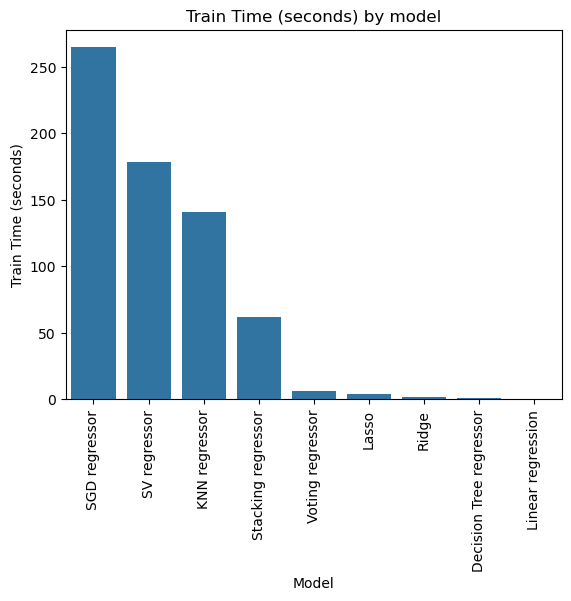

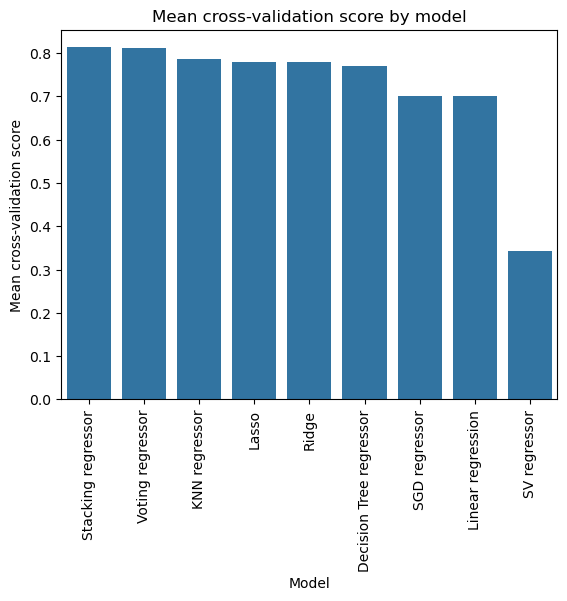

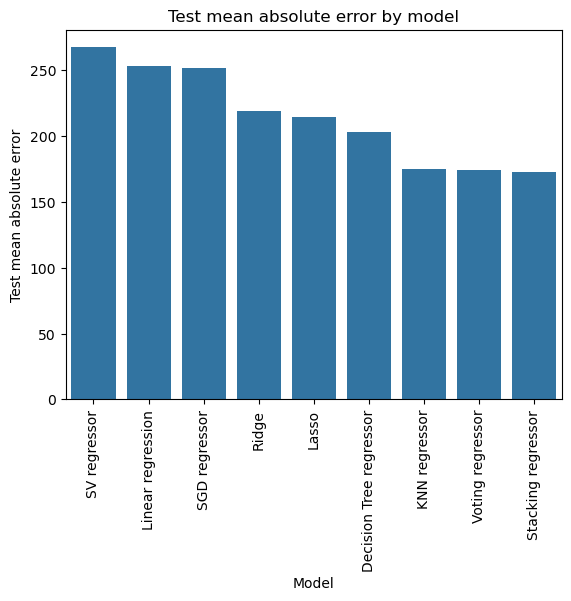

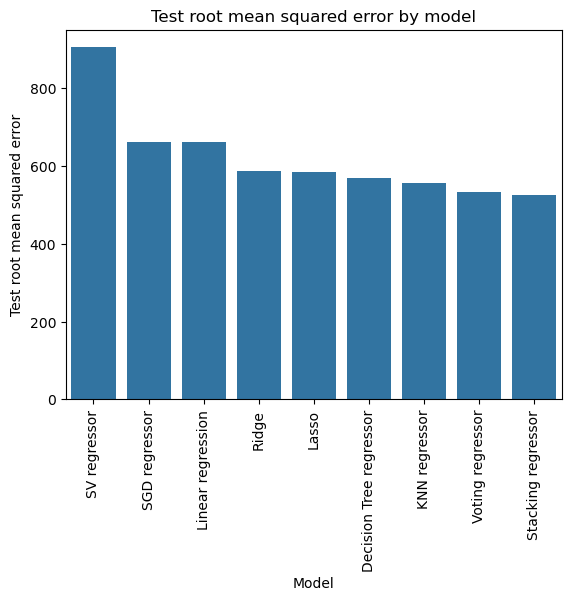

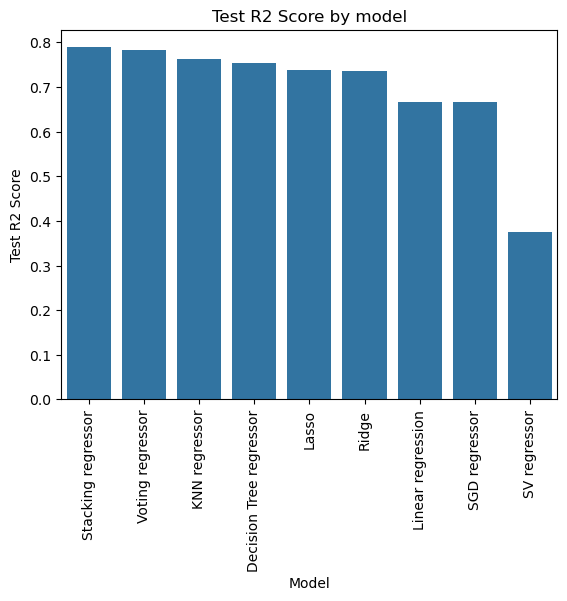

In [22]:
# We plot the Regression models results
results_regression_df = results_regression_df.rename(columns = {'Train Time':'Train Time (seconds)', 'CV score':'Mean cross-validation score', 'Test MAE':'Test mean absolute error',
                                                      'Test RMSE':'Test root mean squared error'})
list_ylabel = ['Train Time (seconds)', 'Mean cross-validation score', 'Test mean absolute error', 'Test root mean squared error', 'Test R2 Score']

for ylabel in list_ylabel:
    df_plot = results_regression_df.sort_values(by=ylabel, ascending=False)
    
    sns.barplot(x='Model', y=ylabel, data=df_plot).tick_params(axis='x', labelrotation=90)
    # Customize ticks
    plt.title(ylabel + ' by model')
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    # Save figure to PNG file
    plt.savefig('images/Model_improvement/Regression models results - ' + ylabel + ' by model.png', bbox_inches='tight')
    plt.show()

From the above results we can see that:
- We made a research for the best regression models according to each of the following scoring methods: neg_mean_absolute_error, neg_root_mean_squared_error, r2. The scoring method which overall provided the best models seems to be the r2 scoring method as we can see from the above table where column "Performance metric" shows either r2 or none
- the fastest model to train are the Linear regression, Decision Tree regressor, Ridge, Lasso and Voting regressor which take less than a minute. The slowest model to train is the Stochastic Gradient Descent Regressor which takes around 4 minutes 30 seconds.
- the models with the highest mean cross-validation score are the Stacking regressor and the Voting regressor with a mean cross-validation score around 0.81
- the model with the lowest test mean absolute error is the Stacking regressor with a test mean absolute error around 172
- the model with the lowest test root mean squared error is the Stacking regressor with a test root mean squared error around 526
- the model with the highest test R2 score is the Stacking regressor with a test R2 score close to 0.79
- the model with the worst mean cross-validation score, test mean absolute error, test root mean squared error and test R2 score is the Support Vector Regressor
- all the models have better performance metrics than the baseline regression model


#### 3. Performance metrics of the best regressor models

The best regression models is the Stacking regressor, which has the final estimator Ridge and 7 estimators models

In [72]:
df_r['amount_raised'].describe()

count    18472.000000
mean       669.302999
std       1171.050702
min        100.000000
25%        225.000000
50%        250.000000
75%        700.000000
max       9900.000000
Name: amount_raised, dtype: float64

##### a. MAE (Mean absolute error): 172.3
- **Interpretation**: MAE calculates the average size of prediction errors, ignoring whether they are positive or negative. It’s the mean of the absolute gaps between predicted and actual values in the test set, giving equal importance to every error. It is less sensitive to outliers and does not emphasize larger errors compared to RMSE.
- **How good is it?**: In this case, a MAE of 172.3 means that on average, our predictions on the amount to raise are off by 172.3. 
So, when predicting the amount that a poker player needs to raise, in a game where the starting stack amount is 10000 and the minimum bet is 100, if the model predicts an amount to raise of 600, we can expect the actual amount to raise to be anywhere between 427.7 and 772.3

##### b. RMSE (Root Mean Squared Error): 526.33
- **Interpretation**: RMSE is a measure of the average magnitude of error between the model's predictions and the actual values. It increases the weight of the bigger errors due to squaring. 
- **How good is it?**: The RMSE of our model is 526.33. This indicates that, in a game where the starting stack amount is 10000 and the minimum bet is 100, the standard deviation of our prediction errors is roughly 526.33. Essentially, this tells us that our predictions are scattered on average by 526.33 from the actual amount to raise.

##### c. R² (Coefficient of Determination): 0.788685
- **Interpretation**: R² indicates the proportion of the variance in the data that is explained by the model. A R² of 0.79 means that 79% of the variation in the amount raised by the player can be explained by the variables in the model.
- **How good is it?**: A R² close to 1 indicates that the model has a very good fit. In this case, a value of 0.79 is a good sign that the model is capturing a significant amount of the variability in the data, though there is still 21% of the variation that the model does not explain.

Given that the RMSE is a bit high and the R² is only 0.79, the model is not perfect, but it already offers clear insights into which factors are driving the amount that the player needs to raise

## Final summary and findings:

- Based on the input data, the model should be able to make 2 predictions:
    - What the player's next action should be (fold, check/call, or raise). For each move there is only one of those 3 choices. For this point, we improved a classification model to predict the action
    - In case the action predicted is "raise", what should be the best amount to raise to be the most profitable possible. In the other cases when the choice was fold or check/call, there is no need to predict any amount as the player won't need to bet anything. For this point, we improved a regression model to predict the amount to raise. 
- For feature engineering, we have enriched the data with many columns calculated from the player or community cards. For example, the number of pairs, sets, quads for the player or community cards; or the number of cards which have potential to make a straight or a flush. It allowed us to have more features available to use for our models.
- The dataset has 3 classes (0 - Fold, 1 - Check/call, 2 - Raise) and the class percentage is 53%, 27% and 20%. The dataset is imbalanced.
- To be successful in a poker game, it is more important to be correct when the player raises, because he takes the risk to lose money. In case the player is incorrect when he folds, it is not as important because he will not lose money. Therefore, we will be looking to have a good precision metric. In our problem, the negative class should be the action: Fold, and the positive class is the action Call or Raise. It is important to minimize the number of false positives because being wrong can cause a loss of money. Additionally, in some cases it is also important not to miss strong hands: so not to fold when we have strong hands. Because this can cause the player to miss on potential good gains. Therefore, for this imbalanced poker dataset, we focused more to have good precision, recall, or F1 score.
- In the previous notebook, we created a baseline classification model, which has train accuracy, test accuracy, test recall (weighted avg) around 0.74, and a test precision and F1 (weighted avg) around 0.73. The goal was to improve the baseline model.
- Classification models with 15 features:
     - all the classification models have better performance metrics than the baseline classification model except the Gaussian Naive Bayes model
     - the top 3 features are: Cards score, Amount required and Chen score.
     - the best classification models with 15 features are the Stacking Classifier and XGBoost Classifier:
          - Our models have 86% accuracy; this means that 86 out of 100 predictions are correct. Accuracy is easy to interpret but can be misleading in imbalanced datasets, which is our case since we have an imbalanced dataset
          - Our model's recall is 0.86, this means that it was able to find 86% of all positive cases.
          - Our model's precision is 0.86, this means that 86% of the actions the model identified as positive cases are actual positive cases
          - Our F1 score of 0.86 indicates that the model is fairly good at identifying positive cases without labeling too many false positives or missing too many actual positives. This score is generally considered quite good for most classification tasks. It is useful for balancing precision and recall and for dealing with our imbalanced dataset
          - Our AUC of 0.95 means that there is 95% chance that the model will be able to distinguish between positive class and negative class.
- In the previous notebook, we created a baseline regression model, which has test mean absolute error around 452, test root mean squared error around 947, test R2 score around 0.31. The goal was to improve the baseline model
- Regression models with 15 features:
     - all the models have better performance metrics than the baseline regression model
     - the top 3 features are Amount required, Amount committed and Stage of the game.
     - Players will bet more if the previous players already betted an important amount or if they already committed a great amount in the pot or as we advance further into the game's stages. Players will bet less if the community cards show that there is potential for a straight, a flush, or if there are pairs
     - the best regression models with 15 features is the Stacking regressor, which has:
          - a MAE (Mean absolute error) of 172.3, which means that on average, our predictions on the amount to raise are off by 172.3. So, when predicting the amount that a poker player needs to raise, in a game where the starting stack amount is 10000 and the minimum bet is 100, if the model predicts an amount to raise of 600, we can expect the actual amount to raise to be anywhere between 427.7 and 772.3
          - a RMSE (Root Mean Squared Error) of 526.33, which indicates that, in a game where the starting stack amount is 10000 and the minimum bet is 100, the standard deviation of our prediction errors is roughly 526.33. Essentially, this tells us that our predictions are scattered on average by 526.33 from the actual amount to raise.
          - A R² of 0.79 which means that 79% of the variation in the amount raised by the player can be explained by the variables in the model. A R² close to 1 indicates that the model has a very good fit. In this case, a value of 0.79 is a good sign that the model is capturing a significant amount of the variability in the data, though there is still 21% of the variation that the model does not explain.
          - Given that the RMSE is a bit high and the R² is only 0.79, the model is not perfect, but it already offers clear insights into which factors are driving the amount that the player needs to raise
- By reducing the number of features to 5 using backward sequential feature selection to improve the KNN regressor model, we were able to further improve the test mean absolute error to 161, the test root mean squared error to 521 and the test R2 to 0.7928


## Recommendations:

For the next steps, we could:
- Make all our models play against each other’s using a poker game engine. Then create some tournaments to figure out which models beat the others in real poker games. We could explore if the winners will be the same ones that we found have the best performance metrics in this notebook : I will do this in the next notebook: 05_game_testing.ipynb
- Using the best model in the PKL file, we could produce an API which will load the model from the file. Then we could make calls to the API using a front-end application : streamlit. It is a user interface framework that will call the API in order to produce predictions and display that on the screen: I will do this in the attached files API_endpoint.py and UI_app.py
- Once we have poker models which can play against each other’s, we could analyze the logs of the games they play, to see if it would make sense to retrain some new models based on what those poker models have already been playing, after recreating some new datasets of their new games. We could also add a part of randomness in what the models play and then select in new datasets only the successful games. We could explore this possibility to see if it would make any impact or improve the strength of the poker models
- We could ask some human poker players to play against the AI poker models we created and ask the human players for feedback to see if they think those are good AI models or not